# Distribution plots

Imports libraries, defines file paths, and loads the filtered clustered CSV. Sets up the output directory for all downstream analysis plots.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# -------------------------
# Paths (EDIT THESE)
# -------------------------
CSV_PATH = Path(r"D:\Kajsa\Dardel\Donor_F2\Nuclei_pos_csv\combined_filtered_merged_clustered_filtered.csv")
BASE_DIR = Path(r"D:\Kajsa\Dardel")
OUT_DIR  = BASE_DIR / "analysis_plots"
OUT_DIR.mkdir(exist_ok=True)

# -------------------------
# Settings
# -------------------------
ROI_COL = "roi_name"
CLUSTER_COL = "cluster"
CELLTYPE_COL = "cell_type"
DOM_CELLTYPE_COL = "dominant_cell_type"
IMAGESTEM_COL = "image_stem"

# New grouping order
desired_order = ['T1D','T2D','Pre-diabetes','BMI >30','BMI <30']

# --- Normalize bar groups (alpha/beta/delta) to 100% ---
# Put BETA FIRST to make it bottom in the stacked bars
bar_groups = ['beta', 'alpha', 'delta']

# Table groups remain as-is
table_groups = ['multihormonal', 'non hormone signal cell']

# -------------------------
# Helpers
# -------------------------

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 18
})

def format_count(n: int) -> str:
    try:
        return str(int(n))
    except Exception:
        return str(n)

def extract_donor_from_imagestem(s: str):
    if not isinstance(s, str):
        return np.nan
    m = re.search(r"ROI[_\-\s]*\d+[_\-\s]*([A-Za-z0-9]+)[_\-\s]", s)
    return m.group(1) if m else np.nan

def donor_display(d: str):
    s = str(d)
    if s.startswith('Donor_'):
        s = s.split('Donor_', 1)[1]
    return s.split('_')[0]

def reorder_present_groups(present_groups):
    ordered = [g for g in desired_order if g in present_groups]
    if 'BMI_unknown' in present_groups:
        ordered.append('BMI_unknown')
    for g in present_groups:
        if g not in ordered:
            ordered.append(g)
    return ordered


def plot_stacked_pct_with_table(
    plot_pct_df: pd.DataFrame,
    bar_groups: list,
    colors: dict,
    out_path: Path,
    title: str,
    xlabels: list,
    cells_counts: pd.Series,
    islets_counts: pd.Series,
    *,
    table_groups: list = None,
    table_fontsize: int = 10,
    x_label: str = "Donor",
    legend_title: str = "Cell type",
    gap_mask=None,
    gap_extra=1.8,
    LEFT_PAD=2.8,
    STEP=2,
    width_frac=0.78,
    Y_ISLETS=112,
    Y_CELLS=106,
    Y_LIM_TOP=120,
    seg_label_min_pct=1.0,
    top_fontsize=9,
    seg_fontsize=12,           # <-- bigger % labels in bars
    group_bounds=None,
    group_y_line=118,
    group_y_text=120,
    group_y_sub=119,
    main_height=4.6,
    table_height=0.75,
):
    rows = list(plot_pct_df.index)
    N = len(rows)
    if N == 0:
        print(f"[skip] {title}: empty dataframe")
        return

    if table_groups is None:
        table_groups = []

    # gap mask
    if gap_mask is None:
        is_gap = np.array([False] * N)
    elif callable(gap_mask):
        is_gap = np.array([bool(gap_mask(r)) for r in rows])
    else:
        is_gap = np.array(gap_mask, dtype=bool)

    # counts aligned
    cells_counts = cells_counts.reindex(rows).fillna(0).astype(int)
    islets_counts = islets_counts.reindex(rows).fillna(0).astype(int)

    # x positions
    x = np.zeros(N, dtype=float)
    cur = LEFT_PAD
    GAP_STEP_FRAC = 0.5
    for i in range(N):
        x[i] = cur
        cur += (STEP * GAP_STEP_FRAC + gap_extra) if is_gap[i] else STEP

    width = STEP * width_frac

    # figure / axes
    fig_w = max(10, 0.28 * cur + 3.0)
    fig_h = main_height + (table_height if table_groups else 0.0)
    fig = plt.figure(figsize=(fig_w, fig_h))

    if table_groups:
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[main_height, table_height], hspace=0.01)
        ax = fig.add_subplot(gs[0, 0])
        ax_tbl = fig.add_subplot(gs[1, 0], sharex=ax)
    else:
        ax = fig.add_subplot(111)
        ax_tbl = None

    # stacked bars (ONLY bar_groups)
    bottom = np.zeros(N, dtype=float)
    for g in bar_groups:
        vals = plot_pct_df[g].values if g in plot_pct_df.columns else np.zeros(N)
        ax.bar(x, vals, width=width, bottom=bottom, color=colors.get(g, None), label=g)
        bottom += vals

    # segment labels
    for i in range(N):
        if is_gap[i]:
            continue
        cum = 0.0
        for g in bar_groups:
            val = float(plot_pct_df.iloc[i][g]) if g in plot_pct_df.columns else 0.0
            if val >= seg_label_min_pct:
                ax.text(
                    x[i], cum + val/2.0, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=seg_fontsize,
                    fontweight="bold"
                )
            cum += val

    # axes main
    ax.set_ylabel("Cells (%)")
    ax.set_xlabel(x_label)
    ax.set_title(title)
    ax.set_ylim(0, Y_LIM_TOP)

    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.set_xlim(-0.5, cur - STEP * 0.2)

    # Hide y-axis labels above 100% BUT keep the space/range
    try:
        yt = ax.get_yticks()
        ax.set_yticks(yt)  # keep same ticks
        ax.set_yticklabels([str(int(y)) if y <= 100 else "" for y in yt])
    except Exception:
        pass

    # left labels islets/cells
    x0, x1 = ax.get_xlim()
    x_label_pos = x0 + 0.02 * (x1 - x0)
    ax.text(x_label_pos, Y_ISLETS, "islets:", ha="left", va="center",
            fontsize=top_fontsize, fontweight="bold")
    ax.text(x_label_pos, Y_CELLS, "cells:", ha="left", va="center",
            fontsize=top_fontsize, fontweight="bold")

    for i, r in enumerate(rows):
        if is_gap[i]:
            continue
        ax.text(x[i], Y_ISLETS, format_count(islets_counts.loc[r]),
                ha="center", va="center", fontsize=top_fontsize, fontweight="bold")
        ax.text(x[i], Y_CELLS,  format_count(cells_counts.loc[r]),
                ha="center", va="center", fontsize=top_fontsize, fontweight="bold")

    # group brackets
    if group_bounds:
        for grp, start, end in group_bounds:
            if start < 0 or end >= N or end < start:
                continue
            left = x[start] - width/2
            right = x[end] + width/2
            ax.hlines(group_y_line, left, right, colors='k', linewidth=1.2)
            center = (left + right) / 2.0
            # keep your ND rendering logic
            if isinstance(grp, str) and grp.startswith("BMI"):
                ax.text(center, group_y_text, "ND", ha="center", va="bottom",
                        fontsize=9, fontweight="bold")
                ax.text(center, group_y_sub, grp, ha="center", va="bottom", fontsize=9)
            else:
                ax.text(center, group_y_text, grp, ha="center", va="bottom",
                        fontsize=9, fontweight="bold")

    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")

    # ---- table coloring helpers ----
    def _shade_from_pct(pct, base_rgb, min_alpha=0.05, max_alpha=0.95):
        """
        Higher contrast than before: darkest is darker.
        Clamp at 60 like before.
        """
        pct = float(pct)
        pct = 0.0 if np.isnan(pct) else max(0.0, min(60.0, pct))
        a = min_alpha + (max_alpha - min_alpha) * (pct / 60.0)
        return (base_rgb[0], base_rgb[1], base_rgb[2], a)

    def _make_cmap(base_rgb):
        return mcolors.LinearSegmentedColormap.from_list(
            "fade", [(1, 1, 1, 1), (*base_rgb, 1)]
        )

    BLUE = (70/255, 130/255, 180/255)
    ORANGE = (255/255, 140/255, 0/255)

    # colorbars (optional)
    if table_groups:
        fig.subplots_adjust(right=0.80)
        cmap_blue = _make_cmap(BLUE)
        cmap_orange = _make_cmap(ORANGE)
        norm = mcolors.Normalize(vmin=0, vmax=60)

        if ax_tbl is not None:
            y0 = 0.12
            h = 0.18
        else:
            y0 = 0.18
            h = 0.22

        x0 = 0.83
        w = 0.020
        gap = 0.06

        cax1 = fig.add_axes([x0, y0 + h + gap, w, h])
        sm1 = plt.cm.ScalarMappable(norm=norm, cmap=cmap_blue)
        cb1 = fig.colorbar(sm1, cax=cax1)
        cb1.set_ticks([0, 20, 40, 60])
        cb1.ax.tick_params(labelsize=8)
        cb1.set_label("Non-hormone (%)", fontsize=8)

        cax2 = fig.add_axes([x0, y0, w, h])
        sm2 = plt.cm.ScalarMappable(norm=norm, cmap=cmap_orange)
        cb2 = fig.colorbar(sm2, cax=cax2)
        cb2.set_ticks([0, 20, 40, 60])
        cb2.ax.tick_params(labelsize=8)
        cb2.set_label("Multihormonal (%)", fontsize=8)

    # table under plot
    if ax_tbl is not None and table_groups:
        ROW_H = 0.70
        ax_tbl.set_ylim(0, len(table_groups) * ROW_H)
        ax_tbl.set_yticks((np.arange(len(table_groups)) + 0.5) * ROW_H)
        ax_tbl.set_yticklabels(table_groups, fontsize=table_fontsize)
        ax_tbl.set_facecolor("white")
        ax_tbl.set_xlabel("")

        ax_tbl.tick_params(axis='x', which='both', length=0, labelbottom=True)
        ax_tbl.set_xticks(x)
        ax_tbl.set_xticklabels(
            [xlabels[i] if not is_gap[i] else "" for i in range(N)],
            rotation=0, ha="center", fontsize=table_fontsize
        )

        for spine in ['top', 'right', 'left', 'bottom']:
            ax_tbl.spines[spine].set_visible(False)

        TABLE_BOX_HEIGHT = 0.45

        for i, r in enumerate(rows):
            if is_gap[i]:
                continue
            for j, g in enumerate(table_groups):
                val = float(plot_pct_df.loc[r, g]) if (g in plot_pct_df.columns and r in plot_pct_df.index) else 0.0
                if g == 'non hormone signal cell':
                    face = _shade_from_pct(val, BLUE)
                elif g == 'multihormonal':
                    face = _shade_from_pct(val, ORANGE)
                else:
                    face = (0, 0, 0, 0)

                y_center = (j + 0.5) * ROW_H
                y0r = y_center - TABLE_BOX_HEIGHT / 2

                rect = plt.Rectangle(
                    (x[i] - width/2, y0r),
                    width,
                    TABLE_BOX_HEIGHT,
                    facecolor=face,
                    edgecolor=(0, 0, 0, 0.35),
                    linewidth=0.8
                )
                ax_tbl.add_patch(rect)

    # use FIG methods (avoids patched plt.savefig recursion)
    try:
        fig.tight_layout(rect=[0, 0, 0.80, 1])
    except Exception:
        pass
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


# -------------------------
# Load data
# -------------------------
base_search = BASE_DIR if BASE_DIR.exists() else CSV_PATH.parent
donor_dirs = sorted([p for p in base_search.iterdir() if p.is_dir() and p.name.startswith("Donor_")])

if donor_dirs:
    dfs = []
    missing = []
    for d in donor_dirs:
        csv_candidate = d / "Nuclei_pos_csv" / "combined_filtered_merged_clustered_filtered.csv"
        if csv_candidate.exists():
            tmp = pd.read_csv(csv_candidate)
            tmp['donor_folder'] = d.name
            dfs.append(tmp)
        else:
            missing.append(str(csv_candidate))
    if not dfs:
        raise FileNotFoundError("No donor CSVs found (checked paths):\n" + "\n".join(missing))
    df = pd.concat(dfs, ignore_index=True)
    OUT_DIR = base_search / "analysis_plots"
    OUT_DIR.mkdir(exist_ok=True)
elif CSV_PATH.is_file():
    df = pd.read_csv(CSV_PATH)
else:
    raise FileNotFoundError(f"No donor directories found under {base_search} and no CSV file at {CSV_PATH}")

if "donor" not in df.columns:
    if 'donor_folder' in df.columns:
        df['donor'] = df['donor_folder']
    elif IMAGESTEM_COL in df.columns:
        df["donor"] = df[IMAGESTEM_COL].apply(extract_donor_from_imagestem)
    else:
        raise ValueError(f"Missing both 'donor' and '{IMAGESTEM_COL}' in CSV.")
df = df.dropna(subset=["donor"]).copy()

df[CLUSTER_COL] = pd.to_numeric(df[CLUSTER_COL], errors="coerce").fillna(0).astype(int)
dfc = df[df[CLUSTER_COL] > 0].copy()
dfc['donor_base'] = dfc['donor'].apply(donor_display)
dfc['cluster_uid'] = dfc['donor'].astype(str) + "__" + dfc[CLUSTER_COL].astype(str)

if dfc.empty:
    raise RuntimeError("No islets cells found (cluster > 0). Nothing to plot.")

# -------------------------
# Load donor metadata and map to disease groups
# -------------------------
meta_path = base_search / 'human_donor_info_Camunas_Pancreas.csv'
meta_map = {}
if meta_path.exists():
    meta = pd.read_csv(meta_path, dtype=str).fillna('')
    if 'index' in meta.columns:
        meta['donor_key'] = meta['index'].astype(str).str.strip()
    elif 'Donor ID' in meta.columns:
        meta['donor_key'] = meta['Donor ID'].astype(str).str.strip()
    else:
        meta['donor_key'] = meta.iloc[:, 0].astype(str).str.strip()

    def is_yes(x):
        return str(x).strip().lower() in ('yes', 'y', 'true', '1')

    def disease_group_from_row(r):
        cols = set(map(str, r.index))
        if 'T1D' in cols and is_yes(r.get('T1D', '')):
            return 'T1D'
        if 'T2D' in cols and is_yes(r.get('T2D', '')):
            return 'T2D'

        # HbA1c >= 5.7
        if 'HbA1c (%)' in r.index:
            try:
                hba = float(str(r['HbA1c (%)']).replace('%', '').replace(',', '.').strip())
            except Exception:
                hba = None
            if hba is not None and hba >= 5.7:
                return 'Pre-diabetes'

        # BMI bins
        bmi_col = None
        if 'BMI' in cols:
            bmi_col = 'BMI'
        else:
            for col in r.index:
                if str(col).strip().lower().startswith('bmi'):
                    bmi_col = col
                    break

        if bmi_col is not None:
            v = str(r.get(bmi_col, '')).strip()
            try:
                bmi_val = float(v)
            except Exception:
                bmi_val = None
            if bmi_val is not None:
                return 'BMI >30' if bmi_val > 30 else 'BMI <30'
        return 'BMI_unknown'

    meta['Disease group'] = meta.apply(disease_group_from_row, axis=1)
    meta_map = dict(zip(meta['donor_key'].astype(str), meta['Disease group'].astype(str)))

def find_group_for_donor(d):
    k = str(d).replace('Donor_', '').strip()
    first = k.split('_')[0]
    if first in meta_map:
        return meta_map[first]
    for mk in meta_map:
        if mk.lower() == first.lower():
            return meta_map[mk]
    if k in meta_map:
        return meta_map[k]
    for mk in meta_map:
        if mk.lower() == k.lower():
            return meta_map[mk]
    return 'none'

donors_all = sorted([str(x) for x in dfc['donor_base'].unique().tolist()])
donor_meta_df = pd.DataFrame({'donor_base': donors_all})
donor_meta_df['Disease group'] = donor_meta_df['donor_base'].apply(find_group_for_donor)
donor_meta_df['Disease group'] = donor_meta_df['Disease group'].replace({
    'BMI <30': 'ND - Lean',
    'BMI >30': 'ND - Obese',
})

# -------------------------
# Cell type mapping
# -------------------------
def map_celltype_to_group(ct):
    if pd.isna(ct):
        return 'other'
    s = str(ct).strip().lower()
    if s == 'alpha':
        return 'alpha'
    if s == 'beta':
        return 'beta'
    if s == 'delta':
        return 'delta'
    if s in ('nuclei', 'nucleus', 'nuclei:'):
        return 'non hormone signal cell'
    if '-' in s or ('alpha' in s and 'beta' in s) or ('alpha' in s and 'delta' in s) or ('beta' in s and 'delta' in s):
        return 'multihormonal'
    return 'other'

dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

selected_groups = ['alpha', 'beta', 'delta', 'non hormone signal cell', 'multihormonal']
cells_by_donor_type = (
    dfc.groupby(['donor_base', 'Cell type'])
       .size()
       .unstack(fill_value=0)
       .reindex(columns=selected_groups, fill_value=0)
).reindex(index=donors_all, fill_value=0)

cells_by_donor_pct = cells_by_donor_type.div(cells_by_donor_type.sum(axis=1).replace(0, 1), axis=0) * 100

# pastel colors
colors = {
    'alpha':   (1.00, 0.70, 0.70),
    'beta':    (0.70, 0.92, 0.70),
    'delta':   (0.80, 0.70, 0.92),
    'non hormone signal cell': (0.75, 0.80, 0.95),
    'multihormonal': (1.00, 0.85, 0.65),
}

# -------------------------
# Plot 1: islets per donor
# -------------------------
clusters_per_donor = dfc.groupby("donor_base")['cluster_uid'].nunique()

# -------------------------
# Plot 2A: per donor (no gaps) -- unchanged ordering
# -------------------------
bar_groups_2a = ['beta', 'alpha', 'delta']  # beta at bottom
plot_pct_df = cells_by_donor_pct.copy()
cells_counts = cells_by_donor_type.sum(axis=1).reindex(plot_pct_df.index, fill_value=0)
islets_counts = clusters_per_donor.reindex(plot_pct_df.index, fill_value=0)

# Normalize ONLY the bar groups to sum to 100% (keep table groups as-is)
plot_pct_df_norm = plot_pct_df.copy()
bar_sum = plot_pct_df_norm[bar_groups].sum(axis=1).replace(0, np.nan)
plot_pct_df_norm[bar_groups] = plot_pct_df_norm[bar_groups].div(bar_sum, axis=0) * 100
plot_pct_df_norm[bar_groups] = plot_pct_df_norm[bar_groups].fillna(0)

# --- Plot 2A specific tweaks ---
bar_groups_2a = ['beta', 'alpha', 'delta']  # beta at bottom

plot_stacked_pct_with_table(
    plot_pct_df_norm,
    bar_groups_2a,  # <-- use the Plot 2A order only
    colors,
    OUT_DIR / "01_cells_per_donor_stacked_pct.png",
    "Cell type composition per donor (islet cells)",
    [donor_display(d) for d in plot_pct_df_norm.index],
    cells_counts,
    islets_counts,
    x_label="Donor",
    legend_title="Cell type",
    LEFT_PAD=2.8,
    STEP=2,
    width_frac=0.78,
    table_groups=table_groups,

    # % label size:
    seg_fontsize=10,   # try 10–12
)


# -------------------------
# Plot 2B: grouped by disease + ORDER donors within each disease by beta% (low->high)
# -------------------------
# beta% per donor from normalized df (bar_groups are normalized to 100)
beta_pct = plot_pct_df_norm['beta'].reindex(donors_all).fillna(0)

# base group series
grouped = donor_meta_df.set_index('donor_base')['Disease group'].reindex(donors_all)
unique_present = reorder_present_groups(list(dict.fromkeys(grouped.dropna().tolist())))

new_index = []
group_bounds = []

for gi, grp in enumerate(unique_present):
    donors_in_group = grouped[grouped == grp].index.tolist()

    # sort by beta abundance (low->high)
    donors_in_group = sorted(donors_in_group, key=lambda d: float(beta_pct.get(d, 0.0)))

    start = len(new_index)
    new_index.extend(donors_in_group)
    end = len(new_index) - 1
    group_bounds.append((grp, start, end))

    if gi < len(unique_present) - 1:
        next_grp = unique_present[gi + 1]
        if next_grp == 'BMI_unknown':
            new_index.append(f'__gap_{gi}__')
            new_index.append(f'__gap_{gi}__extra')
        else:
            new_index.append(f'__gap_{gi}__')

plot_pct_df = cells_by_donor_pct.reindex(new_index, fill_value=0)
cells_counts = cells_by_donor_type.sum(axis=1).reindex(plot_pct_df.index, fill_value=0)
islets_counts = clusters_per_donor.reindex(plot_pct_df.index, fill_value=0)

plot_pct_df_norm = plot_pct_df.copy()
bar_sum = plot_pct_df_norm[bar_groups].sum(axis=1).replace(0, np.nan)
plot_pct_df_norm[bar_groups] = plot_pct_df_norm[bar_groups].div(bar_sum, axis=0) * 100
plot_pct_df_norm[bar_groups] = plot_pct_df_norm[bar_groups].fillna(0)

plot_stacked_pct_with_table(
    plot_pct_df_norm,
    bar_groups,
    colors,
    OUT_DIR / "01_cells_per_donor_stacked_pct_by_disease.png",
    "Cell type composition per donor (grouped by disease; sorted by beta%)",
    [donor_display(d) if not str(d).startswith("__gap_") else "" for d in plot_pct_df_norm.index],
    cells_counts,
    islets_counts,
    x_label="Donor",
    legend_title="Cell type",
    gap_mask=lambda r: str(r).startswith("__gap_"),
    gap_extra=0.0,
    LEFT_PAD=4.5,
    STEP=2,
    width_frac=0.78,
    Y_LIM_TOP=130,
    Y_ISLETS=111,
    Y_CELLS=105,
    group_bounds=group_bounds,
    group_y_line=118,
    group_y_text=120,
    group_y_sub=120,
    table_groups=table_groups,

    # % label size:
    seg_fontsize=9,   # try 10–12
)

# -------------------------
# Plot 2C: aggregated per disease group (no ordering needed)
# -------------------------

def plot_stacked_pct_with_table(
    plot_pct_df: pd.DataFrame,
    bar_groups: list,
    colors: dict,
    out_path: Path,
    title: str,
    xlabels: list,
    cells_counts: pd.Series,
    islets_counts: pd.Series,
    *,
    table_groups: list = None,
    table_fontsize: int = 10,
    x_label: str = "Donor",
    legend_title: str = "Cell type",
    gap_mask=None,
    gap_extra=1.8,
    LEFT_PAD=2.8,
    STEP=2,
    width_frac=0.78,
    Y_ISLETS=112,
    Y_CELLS=106,
    Y_LIM_TOP=120,
    seg_label_min_pct=1.0,
    top_fontsize=9,
    seg_fontsize=12,           # <-- bigger % labels in bars
    group_bounds=None,
    group_y_line=118,
    group_y_text=120,
    group_y_sub=119,
    main_height=4.6,
    table_height=0.75,
):
    rows = list(plot_pct_df.index)
    N = len(rows)
    if N == 0:
        print(f"[skip] {title}: empty dataframe")
        return

    if table_groups is None:
        table_groups = []

    # gap mask
    if gap_mask is None:
        is_gap = np.array([False] * N)
    elif callable(gap_mask):
        is_gap = np.array([bool(gap_mask(r)) for r in rows])
    else:
        is_gap = np.array(gap_mask, dtype=bool)

    # counts aligned
    cells_counts = cells_counts.reindex(rows).fillna(0).astype(int)
    islets_counts = islets_counts.reindex(rows).fillna(0).astype(int)

    # x positions
    x = np.zeros(N, dtype=float)
    cur = LEFT_PAD
    GAP_STEP_FRAC = 0.5
    for i in range(N):
        x[i] = cur
        cur += (STEP * GAP_STEP_FRAC + gap_extra) if is_gap[i] else STEP

    width = STEP * width_frac

    # figure / axes
    fig_w = max(10, 0.28 * cur + 3.0)
    fig_h = main_height + (table_height if table_groups else 0.0)
    fig = plt.figure(figsize=(fig_w, fig_h))

    if table_groups:
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[main_height, table_height], hspace=0.01)
        ax = fig.add_subplot(gs[0, 0])
        ax_tbl = fig.add_subplot(gs[1, 0], sharex=ax)
    else:
        ax = fig.add_subplot(111)
        ax_tbl = None

    # stacked bars (ONLY bar_groups)
    bottom = np.zeros(N, dtype=float)
    for g in bar_groups:
        vals = plot_pct_df[g].values if g in plot_pct_df.columns else np.zeros(N)
        ax.bar(x, vals, width=width, bottom=bottom, color=colors.get(g, None), label=g)
        bottom += vals

    # segment labels
    for i in range(N):
        if is_gap[i]:
            continue
        cum = 0.0
        for g in bar_groups:
            val = float(plot_pct_df.iloc[i][g]) if g in plot_pct_df.columns else 0.0
            if val >= seg_label_min_pct:
                ax.text(
                    x[i], cum + val/2.0, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=seg_fontsize,
                    fontweight="bold"
                )
            cum += val

    # axes main
    ax.set_ylabel("Cells (%)")
    ax.set_xlabel(x_label)
    ax.set_title(title)
    ax.set_ylim(0, Y_LIM_TOP)

    ax.set_xticks(x)
    ax.set_xticklabels([])
    ax.set_xlim(-0.5, cur - STEP * 0.2)

    # Hide y-axis labels above 100% BUT keep the space/range
    try:
        yt = ax.get_yticks()
        ax.set_yticks(yt)  # keep same ticks
        ax.set_yticklabels([str(int(y)) if y <= 100 else "" for y in yt])
    except Exception:
        pass

    # left labels islets/cells
    x0, x1 = ax.get_xlim()
    x_label_pos = x0 + 0.02 * (x1 - x0)
    ax.text(x_label_pos, Y_ISLETS, "islets:", ha="left", va="center",
            fontsize=top_fontsize, fontweight="bold")
    ax.text(x_label_pos, Y_CELLS, "cells:", ha="left", va="center",
            fontsize=top_fontsize, fontweight="bold")

    for i, r in enumerate(rows):
        if is_gap[i]:
            continue
        ax.text(x[i], Y_ISLETS, format_count(islets_counts.loc[r]),
                ha="center", va="center", fontsize=top_fontsize, fontweight="bold")
        ax.text(x[i], Y_CELLS,  format_count(cells_counts.loc[r]),
                ha="center", va="center", fontsize=top_fontsize, fontweight="bold")

    # group brackets
    if group_bounds:
        for grp, start, end in group_bounds:
            if start < 0 or end >= N or end < start:
                continue
            left = x[start] - width/2
            right = x[end] + width/2
            ax.hlines(group_y_line, left, right, colors='k', linewidth=1.2)
            center = (left + right) / 2.0
            # keep your ND rendering logic
            if isinstance(grp, str) and grp.startswith("BMI"):
                ax.text(center, group_y_text, "ND", ha="center", va="bottom",
                        fontsize=9, fontweight="bold")
                ax.text(center, group_y_sub, grp, ha="center", va="bottom", fontsize=9)
            else:
                ax.text(center, group_y_text, grp, ha="center", va="bottom",
                        fontsize=9, fontweight="bold")

    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")

    # ---- table coloring helpers ----
    def _shade_from_pct(pct, base_rgb, min_alpha=0.05, max_alpha=0.95):
        """
        Higher contrast than before: darkest is darker.
        Clamp at 60 like before.
        """
        pct = float(pct)
        pct = 0.0 if np.isnan(pct) else max(0.0, min(60.0, pct))
        a = min_alpha + (max_alpha - min_alpha) * (pct / 60.0)
        return (base_rgb[0], base_rgb[1], base_rgb[2], a)

    def _make_cmap(base_rgb):
        return mcolors.LinearSegmentedColormap.from_list(
            "fade", [(1, 1, 1, 1), (*base_rgb, 1)]
        )

    BLUE = (70/255, 130/255, 180/255)
    ORANGE = (255/255, 140/255, 0/255)

    # colorbars (optional)
    if table_groups:
        fig.subplots_adjust(right=0.80)
        cmap_blue = _make_cmap(BLUE)
        cmap_orange = _make_cmap(ORANGE)
        norm = mcolors.Normalize(vmin=0, vmax=60)

        if ax_tbl is not None:
            y0 = 0.12
            h = 0.18
        else:
            y0 = 0.18
            h = 0.22

        x0 = 0.83
        w = 0.020
        gap = 0.06

        cax1 = fig.add_axes([x0, y0 + h + gap, w, h])
        sm1 = plt.cm.ScalarMappable(norm=norm, cmap=cmap_blue)
        cb1 = fig.colorbar(sm1, cax=cax1)
        cb1.set_ticks([0, 20, 40, 60])
        cb1.ax.tick_params(labelsize=8)
        cb1.set_label("Non-hormone (%)", fontsize=8)

        cax2 = fig.add_axes([x0, y0, w, h])
        sm2 = plt.cm.ScalarMappable(norm=norm, cmap=cmap_orange)
        cb2 = fig.colorbar(sm2, cax=cax2)
        cb2.set_ticks([0, 20, 40, 60])
        cb2.ax.tick_params(labelsize=8)
        cb2.set_label("Multihormonal (%)", fontsize=8)

    # table under plot
    if ax_tbl is not None and table_groups:
        ROW_H = 0.70
        ax_tbl.set_ylim(0, len(table_groups) * ROW_H)
        ax_tbl.set_yticks((np.arange(len(table_groups)) + 0.5) * ROW_H)
        ax_tbl.set_yticklabels(table_groups, fontsize=table_fontsize)
        ax_tbl.set_facecolor("white")
        ax_tbl.set_xlabel("")

        ax_tbl.tick_params(axis='x', which='both', length=0, labelbottom=True)
        ax_tbl.set_xticks(x)
        ax_tbl.set_xticklabels(
            [xlabels[i] if not is_gap[i] else "" for i in range(N)],
            rotation=0, ha="center", fontsize=table_fontsize
        )

        for spine in ['top', 'right', 'left', 'bottom']:
            ax_tbl.spines[spine].set_visible(False)

        TABLE_BOX_HEIGHT = 0.45

        for i, r in enumerate(rows):
            if is_gap[i]:
                continue
            for j, g in enumerate(table_groups):
                val = float(plot_pct_df.loc[r, g]) if (g in plot_pct_df.columns and r in plot_pct_df.index) else 0.0
                if g == 'non hormone signal cell':
                    face = _shade_from_pct(val, BLUE)
                elif g == 'multihormonal':
                    face = _shade_from_pct(val, ORANGE)
                else:
                    face = (0, 0, 0, 0)

                y_center = (j + 0.5) * ROW_H
                y0r = y_center - TABLE_BOX_HEIGHT / 2

                rect = plt.Rectangle(
                    (x[i] - width/2, y0r),
                    width,
                    TABLE_BOX_HEIGHT,
                    facecolor=face,
                    edgecolor=(0, 0, 0, 0.35),
                    linewidth=0.8
                )
                ax_tbl.add_patch(rect)

    # use FIG methods (avoids patched plt.savefig recursion)
    # Give extra room on the left for y-axis label text (fix cropping)
    fig.subplots_adjust(left=0.22, right=0.80)  # <-- increase left as needed

    fig.savefig(out_path, dpi=200)
    plt.close(fig)

disease_map = donor_meta_df.set_index('donor_base')['Disease group'].to_dict()

tmp = cells_by_donor_type.copy()
tmp['Disease group'] = tmp.index.map(lambda d: disease_map.get(d, 'none'))

cells_by_disease_type = tmp.groupby('Disease group')[selected_groups].sum()
cells_by_disease_type = cells_by_disease_type.loc[cells_by_disease_type.sum(axis=1) > 0]

if cells_by_disease_type.empty:
    print("No disease groups with data to plot (aggregated). Skipping aggregated-disease plot.")
else:
    cells_by_disease_pct = cells_by_disease_type.div(cells_by_disease_type.sum(axis=1).replace(0, 1), axis=0) * 100

    if 'BMI_unknown' in cells_by_disease_pct.index:
        cells_by_disease_pct = cells_by_disease_pct.drop('BMI_unknown')
        cells_by_disease_type = cells_by_disease_type.drop('BMI_unknown', errors='ignore')

    present_groups = reorder_present_groups(list(cells_by_disease_pct.index))
    cells_by_disease_pct = cells_by_disease_pct.reindex(present_groups).dropna(how='all')
    cells_by_disease_type = cells_by_disease_type.reindex(cells_by_disease_pct.index)

    clusters_tmp = clusters_per_donor.copy()
    clusters_df = clusters_tmp.to_frame('islets')
    clusters_df['Disease group'] = clusters_df.index.map(lambda d: disease_map.get(d, 'none'))
    disease_islets = clusters_df.groupby('Disease group')['islets'].sum().reindex(cells_by_disease_pct.index, fill_value=0)

    cells_by_disease_pct_norm = cells_by_disease_pct.copy()
    bar_sum = cells_by_disease_pct_norm[bar_groups].sum(axis=1).replace(0, np.nan)
    cells_by_disease_pct_norm[bar_groups] = cells_by_disease_pct_norm[bar_groups].div(bar_sum, axis=0) * 100
    cells_by_disease_pct_norm[bar_groups] = cells_by_disease_pct_norm[bar_groups].fillna(0)

    plot_stacked_pct_with_table(
        cells_by_disease_pct_norm,
        bar_groups,
        colors,
        OUT_DIR / "01_cells_per_disease_stacked_pct.png",
        "Cell type composition per disease group (islet cells)",
        [str(g) for g in cells_by_disease_pct_norm.index],
        cells_by_disease_type.sum(axis=1),
        disease_islets,
        x_label="Disease group",
        legend_title="Cell type",
        LEFT_PAD=1.2,
        STEP=2.1,
        width_frac=0.70,
        table_groups=table_groups,

        # % label size:
        seg_fontsize=9,   # try 10–12
    )

print("Done. Saved updated plots in:", OUT_DIR)


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\3761944711.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.80, 1])
C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\3761944711.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.80, 1])


Done. Saved updated plots in: D:\Kajsa\Dardel\analysis_plots


# Donor-level boxplots per cell-type × condition

For each donor, computes the percentage abundance of each cell type (alpha, beta, delta) across all their islet cells, then plots one boxplot per condition (T1D, T2D, pre-diabetes, BMI bins) where each point represents a single donor.

In [2]:
# -------------------------
# Extra Plot: Donor-level boxplots per cell-type × condition
# - For each donor_base, compute % abundance of each Cell type across all islet cells
# - For each cell type, show one box per condition (T1D, T2D, Pre-diabetes, BMI bins, ...)
# - Each point is one donor_base
# -------------------------

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

selected_groups = [
    'alpha',
    'beta',
    'delta',
]


# If you have this in your project, keep it. Otherwise we fall back safely below.
try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

# Make sure "Cell type" exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# ---- IMPORTANT: use donor_base (since you merged duplicate U7 etc.) ----
DONOR_KEY = 'donor_base' if 'donor_base' in dfc.columns else 'donor'

# Donor x Cell type counts (islet cells only: dfc already filtered by cluster>0)
cells_per_donor = (
    dfc.groupby([DONOR_KEY, 'Cell type'])
       .size()
       .unstack(fill_value=0)
       .reindex(columns=selected_groups, fill_value=0)
)

# Optional: keep your global donor ordering (if exists)
if 'donors_all' in globals():
    # donors_all is your donor_base list in the new pipeline
    cells_per_donor = cells_per_donor.reindex(index=donors_all, fill_value=0)

# Drop donors with zero total
donor_totals = cells_per_donor.sum(axis=1)
cells_per_donor = cells_per_donor.loc[donor_totals > 0]

if cells_per_donor.empty:
    print('No donor-level data available for grouped condition boxplot.')
else:
    # Donor-level % per cell type
    cells_per_donor_pct = cells_per_donor.div(cells_per_donor.sum(axis=1).replace(0, 1), axis=0) * 100

    # ---- Conditions present + ordering ----
    if 'donor_meta_df' in globals() and 'Disease group' in donor_meta_df.columns:
        # donor_meta_df column name depends on your pipeline
        meta_key = 'donor_base' if 'donor_base' in donor_meta_df.columns else 'donor'

        present_groups = []
        for g in desired_order + ['BMI_unknown', 'none']:
            if g in donor_meta_df['Disease group'].values:
                present_groups.append(g)

        # Also include any unexpected groups (at end)
        for g in donor_meta_df['Disease group'].dropna().unique().tolist():
            if g not in present_groups:
                present_groups.append(g)
    else:
        present_groups = ['all']
        meta_key = None

    # Map donor -> group
    if meta_key is not None:
        donor_to_group = donor_meta_df.set_index(meta_key)['Disease group'].to_dict()
    else:
        donor_to_group = {}

    # Condition colors (add anything you use)
    cond_colors = {
        'T1D': (1.00, 0.20, 0.20),
        'T2D': (1.00, 0.85, 0.00),
        'Pre-diabetes': (1.00, 0.55, 0.00),   # orange
        'ND - Lean': (0.70, 0.95, 0.70),
        'ND - Obese': (0.00, 0.45, 0.00),
        'BMI_unknown': (0.80, 0.80, 0.80),
        'none': (0.90, 0.90, 0.90),
        'all': (0.90, 0.90, 0.90),
    }


    # ---- Build data in (cell_type, condition) order ----
    n_types = len(selected_groups)
    n_groups = len(present_groups)
    width = 0.18
    gap = 0.45
    base_positions = np.arange(n_types) * (n_groups * width + gap)

    positions = []
    data_to_plot = []
    colors_list = []
    counts = []

    donors_list = list(cells_per_donor_pct.index)

    for i, ct in enumerate(selected_groups):
        for j, grp in enumerate(present_groups):
            if grp == 'all':
                donors_in_grp = donors_list
            else:
                donors_in_grp = [d for d in donors_list if donor_to_group.get(d, 'none') == grp]

            vals = cells_per_donor_pct.loc[donors_in_grp, ct].dropna().values if donors_in_grp else np.array([])
            data_to_plot.append(vals)

            pos = base_positions[i] + (j - (n_groups - 1) / 2.0) * width
            positions.append(pos)

            colors_list.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    # ---- Plot ----
    fig_w = max(10, 0.9 * n_groups + 1.6 * n_types)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )

    # Color boxes by condition
    for box, col in zip(bp['boxes'], colors_list):
        box.set_facecolor(col)
        box.set_alpha(0.85)
        box.set_edgecolor('k')

    # Overlay donor points
    rng = np.random.RandomState(4)
    for k, arr in enumerate(data_to_plot):
        if arr.size == 0:
            continue
        xs = rng.normal(positions[k], width * 0.06, size=arr.size)
        ax.scatter(xs, arr, color='k', alpha=0.6, s=18)

    # X labels (centered per cell type)
    ax.set_xticks(base_positions)
    ax.set_xticklabels(selected_groups, rotation=0, ha="center")

    # Counts under each cell type
    count_lines = []
    for i in range(n_types):
        seg = counts[i * n_groups:(i + 1) * n_groups]
        count_lines.append(' / '.join(str(x) for x in seg))
    for xi, txt in zip(base_positions, count_lines):
        ax.text(xi, -0.08, txt, ha='center', va='top', fontsize=10, transform=ax.get_xaxis_transform())

    ax.set_ylabel('Abundance (%)')
    ax.set_title('Donor-level % abundance per cell type by condition (each dot = donor)')
    ax.set_ylim(0, 100)

    # Make sure y-axis does not display tick labels above 100%
    try:
        yt = ax.get_yticks()
        ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
    except Exception:
        pass

    # --- Stats: pairwise Mann-Whitney within each cell type, Bonferroni across all tests ---
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations

        comps = []
        for i in range(n_types):
            seg = data_to_plot[i * n_groups:(i + 1) * n_groups]
            valid = [j for j, arr in enumerate(seg) if len(arr) >= 2]
            for a, b in combinations(valid, 2):
                stat, p = mannwhitneyu(seg[a], seg[b], alternative='two-sided')
                comps.append((i, a, b, p))

        n_tests = len(comps)

        def p_to_stars(p):
            if p < 1e-4: return '****'
            if p < 1e-3: return '***'
            if p < 1e-2: return '**'
            if p < 0.05: return '*'
            return ''

        if n_tests > 0:
            y_levels = {i: None for i in range(n_types)}
            for i, a, b, p in comps:
                p_adj = min(p * n_tests, 1.0)
                stars = p_to_stars(p_adj)
                if not stars:
                    continue

                x1 = base_positions[i] + (a - (n_groups - 1) / 2.0) * width
                x2 = base_positions[i] + (b - (n_groups - 1) / 2.0) * width

                seg = data_to_plot[i * n_groups:(i + 1) * n_groups]
                base_y = max(float(np.max(seg[a])) if len(seg[a]) else 0.0,
                             float(np.max(seg[b])) if len(seg[b]) else 0.0)

                if y_levels[i] is None or y_levels[i] < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_levels[i] + 4
                y_levels[i] = y

                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.3, stars, ha='center', va='bottom', fontsize=9)

    except Exception as e:
        print('Skipping statistical tests:', e)

    # Legend (condition colors)
    try:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Condition')
    except Exception:
        pass

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    safe = _sanitize_name('by_condition')
    out_fname = OUT_DIR / f"02_boxplot_celltype_by_condition_{safe}.png"
    plt.savefig(out_fname, dpi=200, bbox_inches='tight')
    plt.close()

    print('Saved:', out_fname)


d:\Kajsa\Experiments\Tissues\Scripts\medium_islets_analysis.py:384: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved size comparison plots: D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_medium.png
Saved: D:\Kajsa\Dardel\analysis_plots\02_boxplot_celltype_by_condition_by_condition.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2460290878.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


## Islet-level boxplots per cell-type × condition

Computes the percentage of each cell type within each individual islet, then plots one boxplot per condition where each data point is a single islet. Captures within-donor islet-to-islet variability in cell-type composition.

In [3]:
# -------------------------
# Islet-level boxplots per cell-type × condition
# - For each islet (cluster_uid), compute % abundance of each Cell type within that islet
# - For each cell type, show one box per condition (T1D, T2D, Pre-diabetes, BMI bins, ...)
# - Each point is one islet/cluster_uid
# -------------------------

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

selected_groups = ['alpha', 'beta', 'delta']

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

# Make sure "Cell type" exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# ---- IMPORTANT: use donor_base (since you merged duplicate U7 etc.) ----
DONOR_KEY = 'donor_base' if 'donor_base' in dfc.columns else 'donor'

# ---- Ensure cluster_uid exists (same logic you used before) ----
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

ISLET_KEY = 'cluster_uid'

# OPTIONAL: keep only plotted groups (removes "other"/non-hormone if not in selected_groups)
dfc_plot = dfc[dfc['Cell type'].isin(selected_groups)].copy()

# Islet x Cell type counts
cells_per_islet = (
    dfc_plot.groupby([ISLET_KEY, 'Cell type'])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=selected_groups, fill_value=0)
)

# Drop islets with zero total
islet_totals = cells_per_islet.sum(axis=1)
cells_per_islet = cells_per_islet.loc[islet_totals > 0]

if cells_per_islet.empty:
    print('No islet-level data available for grouped condition boxplot.')
else:
    # Islet-level % per cell type
    cells_per_islet_pct = cells_per_islet.div(cells_per_islet.sum(axis=1).replace(0, 1), axis=0) * 100

    # ---- Conditions present + ordering ----
    if 'desired_order' not in globals():
        desired_order = ['T1D','T2D','Pre-diabetes','BMI >30','BMI <30','BMI_unknown','none']

    if 'donor_meta_df' in globals() and donor_meta_df is not None and 'Disease group' in donor_meta_df.columns:
        meta_key = 'donor_base' if 'donor_base' in donor_meta_df.columns else ('donor' if 'donor' in donor_meta_df.columns else None)

        if meta_key is None:
            present_groups = ['all']
        else:
            present_groups = []
            for g in desired_order:
                if g in donor_meta_df['Disease group'].values:
                    present_groups.append(g)
            for g in donor_meta_df['Disease group'].dropna().unique().tolist():
                if g not in present_groups:
                    present_groups.append(g)
    else:
        present_groups = ['all']
        meta_key = None

    # Map donor -> group
    donor_to_group = donor_meta_df.set_index(meta_key)['Disease group'].to_dict() if meta_key is not None else {}

    # Map islet -> donor_base (or donor)
    # (Uses first donor in that islet; should be consistent)
    islet_to_donor = dfc_plot.groupby(ISLET_KEY)[DONOR_KEY].first().to_dict()

    # ---- Build data in (cell_type, condition) order ----
    n_types = len(selected_groups)
    n_groups = len(present_groups)
    width = 0.18
    gap = 0.45
    base_positions = np.arange(n_types) * (n_groups * width + gap)

    positions = []
    data_to_plot = []
    colors_list = []
    counts = []

    islets_list = list(cells_per_islet_pct.index)

    for i, ct in enumerate(selected_groups):
        for j, grp in enumerate(present_groups):
            if grp == 'all' or meta_key is None:
                islets_in_grp = islets_list
            else:
                # include islets whose donor is in that disease group
                islets_in_grp = [
                    isl for isl in islets_list
                    if donor_to_group.get(islet_to_donor.get(isl, None), 'none') == grp
                ]

            vals = cells_per_islet_pct.loc[islets_in_grp, ct].dropna().values if islets_in_grp else np.array([])
            data_to_plot.append(vals)

            pos = base_positions[i] + (j - (n_groups - 1) / 2.0) * width
            positions.append(pos)

            colors_list.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    # ---- Plot ----
    # ---- Plot: separate figure per cell type + right-side half-violin KDE + stats ----

    def _kde_1d(y_grid, samples, bw=None):
        x = np.asarray(samples, dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return np.zeros_like(y_grid, dtype=float)

        if bw is None:
            std = np.std(x, ddof=1) if n > 1 else 1.0
            std = std if std > 1e-6 else 1.0
            bw = 1.06 * std * (n ** (-1/5))
            bw = max(bw, 1.5)

        diffs = (y_grid[:, None] - x[None, :]) / bw
        dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
        return dens

    def _p_to_stars(p):
        if p < 1e-4: return '****'
        if p < 1e-3: return '***'
        if p < 1e-2: return '**'
        if p < 0.05: return '*'
        return ''

    # Parameters to tweak
    YMAX = 140
    YSHOW_LABEL_MAX = 100
    KDE_YSTEP = 0.5
    KDE_MAX_WIDTH = 1
    KDE_ALPHA_FILL = 0.18
    KDE_ALPHA_LINE = 0.95
    POINT_ALPHA = 0.55
    POINT_SIZE = 10
    BOX_WIDTH = 0.55
    JITTER_SD = 0.06

    KDE_MAX_WIDTH = 1.70   # <-- was 0.85 (double width)
    KDE_ANCHOR_PAD = 1.15  # (same as before; optional: try 1.25 if you want it a bit more separated)
    KDE_RIGHT_PAD  = 1.20  # <-- was 0.9 (more room so it doesn't get clipped)

    rng = np.random.RandomState(4)
    y_grid = np.arange(0, 100 + KDE_YSTEP, KDE_YSTEP)

    # Precompute islets per condition per cell type
    islets_list = list(cells_per_islet_pct.index)

    panel_data = {ct: {} for ct in selected_groups}
    panel_counts = {ct: {} for ct in selected_groups}

    for ct in selected_groups:
        for grp in present_groups:
            if grp == 'all' or meta_key is None:
                islets_in_grp = islets_list
            else:
                islets_in_grp = [
                    isl for isl in islets_list
                    if donor_to_group.get(islet_to_donor.get(isl, None), 'none') == grp
                ]
            vals = cells_per_islet_pct.loc[islets_in_grp, ct].dropna().values if islets_in_grp else np.array([])
            panel_data[ct][grp] = vals
            panel_counts[ct][grp] = int(vals.size)

    # Stats imports
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations
        HAVE_STATS = True
    except Exception as e:
        print("Stats disabled (missing scipy?):", e)
        HAVE_STATS = False

    # One plot per cell type
    for ct in selected_groups:

        X_SPACING = 1.4   # try 1.3–1.8 depending on how many conditions
        xs = np.arange(len(present_groups), dtype=float) * X_SPACING

        data_list = [panel_data[ct][grp] for grp in present_groups]

        # --- Figure ---
        fig_w = max(10, 0.9 * len(present_groups) + 6)
        fig, ax = plt.subplots(figsize=(fig_w, 6))

        # --- Boxplots ---
        bp = ax.boxplot(
            data_list,
            positions=xs,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False
        )

        for box, grp in zip(bp['boxes'], present_groups):
            col = cond_colors.get(grp, (0.9, 0.9, 0.9))
            box.set_facecolor(col)
            box.set_alpha(0.85)
            box.set_edgecolor('k')

        # --- Jitter points ---
        for j, grp in enumerate(present_groups):
            arr = panel_data[ct][grp]
            if arr.size == 0:
                continue
            xj = rng.normal(xs[j], JITTER_SD, size=arr.size)
            ax.scatter(xj, arr, color='k', alpha=POINT_ALPHA, s=POINT_SIZE, zorder=3)

        # --- Right-side half-violin KDEs (overlaid) ---
        kde_anchor = xs[-1] + KDE_ANCHOR_PAD

        dens_by_grp = {}
        max_d = 0.0
        for grp in present_groups:
            d = _kde_1d(y_grid, panel_data[ct][grp])
            dens_by_grp[grp] = d
            if d.size and np.max(d) > max_d:
                max_d = float(np.max(d))

        # Normalize by panel max so shapes comparable
        for grp in present_groups:
            d = dens_by_grp[grp]
            if max_d > 0:
                d = d / max_d
            dens_by_grp[grp] = d

        for grp in present_groups:
            d = dens_by_grp[grp]
            if np.all(d == 0):
                continue
            col = cond_colors.get(grp, (0.9, 0.9, 0.9))
            x_curve = kde_anchor + d * KDE_MAX_WIDTH
            ax.fill_betweenx(y_grid, kde_anchor, x_curve, facecolor=col, alpha=KDE_ALPHA_FILL, linewidth=0)
            ax.plot(x_curve, y_grid, color=col, alpha=KDE_ALPHA_LINE, linewidth=2.0)

        ax.plot([kde_anchor, kde_anchor], [0, YMAX], color='k', alpha=0.25, linewidth=1.0)

        # --- Stats: Mann–Whitney within this cell type, Bonferroni across tests in THIS figure ---
        if HAVE_STATS:
            comps = []
            valid = [j for j, arr in enumerate(data_list) if len(arr) >= 2]
            for a, b in combinations(valid, 2):
                try:
                    stat, p = mannwhitneyu(data_list[a], data_list[b], alternative='two-sided')
                    comps.append((a, b, p))
                except Exception:
                    continue

            n_tests = len(comps)

            # Place bars above the higher of the two groups, stacking if multiple
            y_level = None
            for a, b, p in comps:
                p_adj = min(p * n_tests, 1.0) if n_tests > 0 else p
                stars = _p_to_stars(p_adj)
                if not stars:
                    continue

                base_y = max(
                    float(np.max(data_list[a])) if len(data_list[a]) else 0.0,
                    float(np.max(data_list[b])) if len(data_list[b]) else 0.0
                )

                if y_level is None or y_level < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_level + 4
                y_level = y

                x1, x2 = xs[a], xs[b]
                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0, stars, ha='center', va='bottom', fontsize=10)

        # --- Labels / formatting ---
        ax.set_ylabel("Abundance (%)")
        ax.set_title(f"Islet-level % abundance: {ct} ")
        ax.set_ylim(0, YMAX)

        yt = ax.get_yticks()
        ax.set_yticks(yt)
        ax.set_yticklabels([str(int(y)) if y <= YSHOW_LABEL_MAX else "" for y in yt])

        ax.set_xticks(xs)
        ax.set_xticklabels(present_groups, rotation=0, ha="center", fontsize=9)

        # counts under each condition
        for j, grp in enumerate(present_groups):
            n = panel_counts[ct][grp]
            ax.text(xs[j], -0.06, str(n), ha='center', va='top', fontsize=9, transform=ax.get_xaxis_transform())

        # xlim to include KDE region
        ax.set_xlim(-0.8, kde_anchor + KDE_MAX_WIDTH + 0.6)

        # legend (conditions)
        try:
            import matplotlib.patches as mpatches
            handles = [mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
            ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Condition')
        except Exception:
            pass

        fig.tight_layout(rect=[0.02, 0.02, 0.82, 0.98])

        safe = _sanitize_name(f"islet_by_condition_KDE_{ct}")
        out_fname = OUT_DIR / f"03_boxplot_islet_celltype_by_condition_{safe}.png"
        fig.savefig(out_fname, dpi=200, bbox_inches='tight')
        plt.close(fig)

        print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\03_boxplot_islet_celltype_by_condition_islet_by_condition_KDE_alpha.png
Saved: D:\Kajsa\Dardel\analysis_plots\03_boxplot_islet_celltype_by_condition_islet_by_condition_KDE_beta.png
Saved: D:\Kajsa\Dardel\analysis_plots\03_boxplot_islet_celltype_by_condition_islet_by_condition_KDE_delta.png


# Islet size per condition with KDE

Plots raw cell counts per islet for each cell type, stratified by condition, with a half-violin KDE overlay on the right. Statistical comparisons use Mann-Whitney U tests with Bonferroni correction within each cell type.

In [4]:
# -------------------------
# Islet-level boxplots per cell-type × condition (COUNTS)
# - For each islet (cluster_uid), compute #cells of each Cell type within that islet
# - For each cell type, show one box per condition
# - Each point is one islet/cluster_uid
# - Right-side: half-violin KDE of the distribution of #cells
# - Stats: Mann-Whitney within each cell type, Bonferroni within figure
# -------------------------

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

selected_groups = ['alpha', 'beta', 'delta']

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

# Make sure "Cell type" exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# ---- IMPORTANT: use donor_base (since you merged duplicate U7 etc.) ----
DONOR_KEY = 'donor_base' if 'donor_base' in dfc.columns else 'donor'

# ---- Ensure cluster_uid exists ----
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

ISLET_KEY = 'cluster_uid'

# OPTIONAL: keep only plotted groups
dfc_plot = dfc[dfc['Cell type'].isin(selected_groups)].copy()

# Islet x Cell type counts
cells_per_islet = (
    dfc_plot.groupby([ISLET_KEY, 'Cell type'])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=selected_groups, fill_value=0)
)

# Drop islets with zero total (across selected groups)
islet_totals = cells_per_islet.sum(axis=1)
cells_per_islet = cells_per_islet.loc[islet_totals > 0]

if cells_per_islet.empty:
    print('No islet-level data available for grouped condition boxplot (counts).')
else:
    # ---- Conditions present + ordering ----
    if 'desired_order' not in globals():
        desired_order = ['T1D','T2D','Pre-diabetes','BMI >30','BMI <30','BMI_unknown','none']

    if 'donor_meta_df' in globals() and donor_meta_df is not None and 'Disease group' in donor_meta_df.columns:
        meta_key = 'donor_base' if 'donor_base' in donor_meta_df.columns else ('donor' if 'donor' in donor_meta_df.columns else None)
        if meta_key is None:
            present_groups = ['all']
        else:
            present_groups = []
            for g in desired_order:
                if g in donor_meta_df['Disease group'].values:
                    present_groups.append(g)
            for g in donor_meta_df['Disease group'].dropna().unique().tolist():
                if g not in present_groups:
                    present_groups.append(g)
    else:
        present_groups = ['all']
        meta_key = None

    # Map donor -> group
    donor_to_group = donor_meta_df.set_index(meta_key)['Disease group'].to_dict() if meta_key is not None else {}

    # Map islet -> donor_base (or donor)
    islet_to_donor = dfc_plot.groupby(ISLET_KEY)[DONOR_KEY].first().to_dict()

    # ---------- helpers: KDE + stats ----------
    def _kde_1d(y_grid, samples, bw=None):
        x = np.asarray(samples, dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return np.zeros_like(y_grid, dtype=float)

        if bw is None:
            std = np.std(x, ddof=1) if n > 1 else 1.0
            std = std if std > 1e-6 else 1.0
            bw = 1.06 * std * (n ** (-1/5))
            bw = max(bw, 1.5)

        diffs = (y_grid[:, None] - x[None, :]) / bw
        dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
        return dens

    def _p_to_stars(p):
        if p < 1e-4: return '****'
        if p < 1e-3: return '***'
        if p < 1e-2: return '**'
        if p < 0.05: return '*'
        return ''

    # Stats imports
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations
        HAVE_STATS = True
    except Exception as e:
        print("Stats disabled (missing scipy?):", e)
        HAVE_STATS = False

    # ---------- plotting params (keep the same style) ----------
    KDE_ALPHA_FILL = 0.18
    KDE_ALPHA_LINE = 1
    POINT_ALPHA = 0.55
    POINT_SIZE = 10
    BOX_WIDTH = 0.55
    JITTER_SD = 0.06
    X_SPACING = 1.4
    KDE_MAX_WIDTH = 0.85

    KDE_MAX_WIDTH = 1.70   # <-- was 0.85 (double width)
    KDE_ANCHOR_PAD = 1.15  # (same as before; optional: try 1.25 if you want it a bit more separated)
    KDE_RIGHT_PAD  = 1.20  # <-- was 0.9 (more room so it doesn't get clipped)

    rng = np.random.RandomState(4)

    # Precompute per-(celltype, condition) arrays of COUNTS
    islets_list = list(cells_per_islet.index)

    panel_data = {ct: {} for ct in selected_groups}
    panel_counts = {ct: {} for ct in selected_groups}

    for ct in selected_groups:
        for grp in present_groups:
            if grp == 'all' or meta_key is None:
                islets_in_grp = islets_list
            else:
                islets_in_grp = [
                    isl for isl in islets_list
                    if donor_to_group.get(islet_to_donor.get(isl, None), 'none') == grp
                ]

            # counts (NOT percent)
            vals = cells_per_islet.loc[islets_in_grp, ct].dropna().values if islets_in_grp else np.array([])
            vals = vals.astype(float)  # KDE likes float
            panel_data[ct][grp] = vals
            panel_counts[ct][grp] = int(vals.size)

    # One plot per cell type
    for ct in selected_groups:

        xs = np.arange(len(present_groups), dtype=float) * X_SPACING
        data_list = [panel_data[ct][grp] for grp in present_groups]

        # Determine Y limits from data (with headroom for stats)
        all_vals = np.concatenate([arr for arr in data_list if arr.size > 0]) if any(a.size > 0 for a in data_list) else np.array([0.0])
        ymax_data = float(np.max(all_vals)) if all_vals.size else 0.0
        YMAX = max(10.0, np.ceil(ymax_data + 15))  # headroom
        YMIN = 0.0

        # KDE grid for counts
        KDE_YSTEP = max(1.0, np.floor((YMAX - YMIN) / 250.0))  # adaptive step so it's not too dense
        y_grid = np.arange(YMIN, YMAX + KDE_YSTEP, KDE_YSTEP)

        # --- Figure ---
        fig_w = max(10, 0.9 * len(present_groups) + 6)
        fig, ax = plt.subplots(figsize=(fig_w, 6))

        # --- Boxplots ---
        bp = ax.boxplot(
            data_list,
            positions=xs,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False
        )

        for box, grp in zip(bp['boxes'], present_groups):
            col = cond_colors.get(grp, (0.9, 0.9, 0.9))
            box.set_facecolor(col)
            box.set_alpha(0.85)
            box.set_edgecolor('k')

        # --- Jitter points ---
        for j, grp in enumerate(present_groups):
            arr = panel_data[ct][grp]
            if arr.size == 0:
                continue
            xj = rng.normal(xs[j], JITTER_SD, size=arr.size)
            ax.scatter(xj, arr, color='k', alpha=POINT_ALPHA, s=POINT_SIZE, zorder=3)

        # --- Right-side half-violin KDEs (overlaid) ---
        kde_anchor = xs[-1] + KDE_ANCHOR_PAD

        dens_by_grp = {}
        max_d = 0.0
        for grp in present_groups:
            d = _kde_1d(y_grid, panel_data[ct][grp])
            dens_by_grp[grp] = d
            if d.size and np.max(d) > max_d:
                max_d = float(np.max(d))

        # Normalize by panel max so shapes comparable
        for grp in present_groups:
            d = dens_by_grp[grp]
            if max_d > 0:
                d = d / max_d
            dens_by_grp[grp] = d

        for grp in present_groups:
            d = dens_by_grp[grp]
            if np.all(d == 0):
                continue
            col = cond_colors.get(grp, (0.9, 0.9, 0.9))
            x_curve = kde_anchor + d * KDE_MAX_WIDTH
            ax.fill_betweenx(y_grid, kde_anchor, x_curve, facecolor=col, alpha=KDE_ALPHA_FILL, linewidth=0)
            ax.plot(x_curve, y_grid, color=col, alpha=KDE_ALPHA_LINE, linewidth=2.0)

        # baseline only over KDE y-range
        ax.plot([kde_anchor, kde_anchor], [YMIN, YMAX], color='k', alpha=0.25, linewidth=1.0)

        # --- Stats: Mann–Whitney within this cell type, Bonferroni within figure ---
        if HAVE_STATS:
            comps = []
            valid = [j for j, arr in enumerate(data_list) if len(arr) >= 2]
            from itertools import combinations
            for a, b in combinations(valid, 2):
                try:
                    stat, p = mannwhitneyu(data_list[a], data_list[b], alternative='two-sided')
                    comps.append((a, b, p))
                except Exception:
                    continue

            n_tests = len(comps)
            y_level = None

            for a, b, p in comps:
                p_adj = min(p * n_tests, 1.0) if n_tests > 0 else p
                stars = _p_to_stars(p_adj)
                if not stars:
                    continue

                base_y = max(
                    float(np.max(data_list[a])) if len(data_list[a]) else 0.0,
                    float(np.max(data_list[b])) if len(data_list[b]) else 0.0
                )

                if y_level is None or y_level < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_level + 4
                y_level = y

                x1, x2 = xs[a], xs[b]
                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0, stars, ha='center', va='bottom', fontsize=10)

        # --- Labels / formatting ---
        ax.set_ylabel("Cells per islet")
        ax.set_title(f"Islet-level counts: {ct}", fontsize=13)
        ax.set_ylim(YMIN, YMAX)

        ax.set_xticks(xs)
        ax.set_xticklabels(present_groups, rotation=0, ha="center", fontsize=9)

        # counts under each condition (number of islets in that group)
        for j, grp in enumerate(present_groups):
            n = panel_counts[ct][grp]
            ax.text(xs[j], -0.06, str(n), ha='center', va='top', fontsize=9, transform=ax.get_xaxis_transform())

        ax.set_xlim(-0.8, kde_anchor + KDE_MAX_WIDTH + KDE_RIGHT_PAD)

        # legend (conditions)
        try:
            import matplotlib.patches as mpatches
            handles = [mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
            ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Condition')
        except Exception:
            pass

        fig.tight_layout(rect=[0.02, 0.02, 0.82, 0.98])

        safe = _sanitize_name(f"islet_by_condition_counts_KDE_{ct}")
        out_fname = OUT_DIR / f"04_boxplot_islet_cellcounts_by_condition_{safe}.png"
        fig.savefig(out_fname, dpi=200, bbox_inches='tight')
        plt.close(fig)

        print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\04_boxplot_islet_cellcounts_by_condition_islet_by_condition_counts_KDE_alpha.png
Saved: D:\Kajsa\Dardel\analysis_plots\04_boxplot_islet_cellcounts_by_condition_islet_by_condition_counts_KDE_beta.png
Saved: D:\Kajsa\Dardel\analysis_plots\04_boxplot_islet_cellcounts_by_condition_islet_by_condition_counts_KDE_delta.png


In [5]:
# -------------------------
# Islet-level TOTAL CELLS per islet by condition (ignoring cell type)
# - For each islet (cluster_uid), compute total #cells (all cell types) in that islet
# - One box per condition (T1D, T2D, Pre-diabetes, BMI bins, ...)
# - Each point = one islet/cluster_uid
# - Right-side: overlaid half-violin KDE lines for each condition
# - Saves TWO images:
#     (A) FULL y-range (data-driven)
#     (B) ZOOM 0–400 with WIDER KDE
# - Stats: pairwise Mann–Whitney across conditions + Bonferroni (within each figure)
# -------------------------

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

# ---- Ensure cluster_uid exists ----
if "cluster_uid" not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc["_roi_int"] = pd.to_numeric(dfc[ROI_COL], errors="coerce").fillna(-1).astype(int)
        dfc["_cluster_int"] = pd.to_numeric(dfc[CLUSTER_COL], errors="coerce").fillna(0).astype(int)
        dfc["cluster_uid"] = dfc["_cluster_int"].astype(str) + "_R" + dfc["_roi_int"].astype(str)
    else:
        dfc["cluster_uid"] = pd.to_numeric(dfc[CLUSTER_COL], errors="coerce").fillna(0).astype(int).astype(str)

ISLET_KEY = "cluster_uid"

# ---- Total cells per islet (ignore cell type completely) ----
cells_total_per_islet = dfc.groupby(ISLET_KEY).size().astype(int)
cells_total_per_islet = cells_total_per_islet[cells_total_per_islet > 0]

if cells_total_per_islet.empty:
    print("No islets found for total-cell counts.")
else:
    # ---- Conditions present + ordering ----
    if "desired_order" not in globals():
        desired_order = ["T1D", "T2D", "Pre-diabetes", "BMI >30", "BMI <30", "BMI_unknown", "none"]

    use_meta = ("donor_meta_df" in globals()) and (donor_meta_df is not None) and ("Disease group" in donor_meta_df.columns)

    if use_meta:
        donor_key_dfc  = _pick_key(dfc, ["donor_base", "donor", "Donor"], "donor (dfc)")
        donor_key_meta = _pick_key(donor_meta_df, ["donor_base", "donor", "Donor"], "donor (donor_meta_df)")

        # condition order
        present_groups = [g for g in desired_order if g in donor_meta_df["Disease group"].values]
        for g in donor_meta_df["Disease group"].dropna().unique().tolist():
            if g not in present_groups:
                present_groups.append(g)

        if "reorder_present_groups" in globals():
            present_groups = reorder_present_groups(present_groups)

        donor_to_group = donor_meta_df.set_index(donor_key_meta)["Disease group"].to_dict()
        islet_to_donor = dfc.groupby(ISLET_KEY)[donor_key_dfc].first().astype(str).to_dict()
    else:
        present_groups = ["all"]
        donor_to_group = {}
        islet_to_donor = {}

    # colors for conditions
    if "cond_colors" in globals():
        cond_cols = cond_colors
    else:
        cmap = plt.get_cmap("tab10")
        cond_cols = {g: cmap(i % 10) for i, g in enumerate(present_groups)}

    # ---- helpers: KDE + stats ----
    def _kde_1d(y_grid, samples, bw=None):
        x = np.asarray(samples, dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return np.zeros_like(y_grid, dtype=float)

        if bw is None:
            std = np.std(x, ddof=1) if n > 1 else 1.0
            std = std if std > 1e-6 else 1.0
            bw = 1.06 * std * (n ** (-1 / 5))
            bw = max(bw, 1.5)

        diffs = (y_grid[:, None] - x[None, :]) / bw
        dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
        return dens

    def _p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 0.05: return "*"
        return ""

    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations
        HAVE_STATS = True
    except Exception as e:
        print("Stats disabled (missing scipy?):", e)
        HAVE_STATS = False

    def _plot_total_cells_box_kde(
        *,
        present_groups,
        panel_data,
        panel_n,
        cond_cols,
        out_path,
        title,
        y_min,
        y_max,
        kde_max_width=0.85,
        kde_alpha_fill=0.18,
        kde_alpha_line=0.95,
        point_alpha=0.55,
        point_size=10,
        box_width=0.55,
        jitter_sd=0.06,
        x_spacing=1.4,
        stats=True,
        fig_w=None,
        fig_h=6,
    ):
        rng = np.random.RandomState(4)

        xs = np.arange(len(present_groups), dtype=float) * x_spacing
        data_list = [panel_data[g].astype(float) for g in present_groups]

        # KDE grid for this figure (fixed to its displayed y-range)
        y_grid = np.linspace(y_min, y_max, 350)

        if fig_w is None:
            fig_w = max(10, 0.9 * len(present_groups) + 6)

        fig, ax = plt.subplots(figsize=(fig_w, fig_h))

        # Boxplots
        bp = ax.boxplot(
            data_list,
            positions=xs,
            widths=box_width,
            patch_artist=True,
            showfliers=False
        )
        for box, grp in zip(bp["boxes"], present_groups):
            col = cond_cols.get(grp, (0.9, 0.9, 0.9))
            box.set_facecolor(col)
            box.set_alpha(0.85)
            box.set_edgecolor("k")

        # Jitter points
        for j, grp in enumerate(present_groups):
            arr = data_list[j]
            if arr.size == 0:
                continue
            xj = rng.normal(xs[j], jitter_sd, size=arr.size)
            ax.scatter(xj, arr, color="k", alpha=point_alpha, s=point_size, zorder=3)

        # Right-side KDE (half-violin) overlaid
        kde_anchor = xs[-1] + 1.15

        dens_by_grp = {}
        max_d = 0.0
        for grp in present_groups:
            d = _kde_1d(y_grid, panel_data[grp])
            dens_by_grp[grp] = d
            if d.size:
                max_d = max(max_d, float(np.max(d)))

        # normalize densities so shapes are comparable
        for grp in present_groups:
            d = dens_by_grp[grp]
            if max_d > 0:
                d = d / max_d
            dens_by_grp[grp] = d

        for grp in present_groups:
            d = dens_by_grp[grp]
            if np.all(d == 0):
                continue
            col = cond_cols.get(grp, (0.9, 0.9, 0.9))
            x_curve = kde_anchor + d * kde_max_width
            ax.fill_betweenx(y_grid, kde_anchor, x_curve, facecolor=col, alpha=kde_alpha_fill, linewidth=0)
            ax.plot(x_curve, y_grid, color=col, alpha=kde_alpha_line, linewidth=2.0)

        ax.plot([kde_anchor, kde_anchor], [y_min, y_max], color="k", alpha=0.25, linewidth=1.0)

        # Stats across conditions (pairwise), Bonferroni within this figure
        # For zoom plot: skip annotations that would land above y_max
        if stats and HAVE_STATS:
            valid = [j for j, arr in enumerate(data_list) if len(arr) >= 2]
            comps = []
            for a, b in combinations(valid, 2):
                try:
                    _, p = mannwhitneyu(data_list[a], data_list[b], alternative="two-sided")
                    comps.append((a, b, p))
                except Exception:
                    continue

            n_tests = len(comps)
            y_level = None
            for a, b, p in comps:
                p_adj = min(p * n_tests, 1.0) if n_tests > 0 else p
                stars = _p_to_stars(p_adj)
                if not stars:
                    continue

                base_y = max(
                    float(np.max(data_list[a])) if len(data_list[a]) else 0.0,
                    float(np.max(data_list[b])) if len(data_list[b]) else 0.0
                )

                if y_level is None or y_level < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_level + 4
                y_level = y

                # skip if outside visible range (for zoom)
                if y > y_max - 2:
                    continue

                x1, x2 = xs[a], xs[b]
                ax.plot([x1, x2], [y, y], color="k", linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.0, stars, ha="center", va="bottom", fontsize=10)

        # labels/formatting
        ax.set_ylabel("Total cells per islet")
        ax.set_title(title, fontsize=13)
        ax.set_ylim(y_min, y_max)

        ax.set_xticks(xs)
        ax.set_xticklabels(present_groups, rotation=0, ha="center", fontsize=9)

        # counts under each condition (number of islets)
        for j, grp in enumerate(present_groups):
            ax.text(xs[j], -0.06, str(panel_n[grp]), ha="center", va="top", fontsize=9,
                    transform=ax.get_xaxis_transform())

        ax.set_xlim(-0.8, kde_anchor + kde_max_width + 0.9)

        # legend (conditions)
        try:
            import matplotlib.patches as mpatches
            handles = [mpatches.Patch(color=cond_cols.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
            ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Condition")
        except Exception:
            pass

        fig.tight_layout(rect=[0.02, 0.02, 0.82, 0.98])
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("Saved:", out_path)

    # ---- Build arrays per condition ----
    all_islets = list(cells_total_per_islet.index)
    panel_data = {}
    panel_n = {}

    for grp in present_groups:
        if grp == "all" or not use_meta:
            islets_in_grp = all_islets
        else:
            islets_in_grp = [
                isl for isl in all_islets
                if donor_to_group.get(islet_to_donor.get(isl, ""), "none") == grp
            ]

        vals = cells_total_per_islet.reindex(islets_in_grp).dropna().values.astype(float)
        panel_data[grp] = vals
        panel_n[grp] = int(vals.size)

    # Keep only conditions that exist + have data (prevents KeyError like 'T1D')
    present_groups = [g for g in present_groups if (g in panel_data) and (panel_n.get(g, 0) > 0)]

    if len(present_groups) == 0:
        print("No conditions with islets to plot.")
    else:
        # FULL y-range: data-driven
        all_vals = np.concatenate([panel_data[g] for g in present_groups if panel_data[g].size > 0])
        ymax_data = float(np.max(all_vals)) if all_vals.size else 0.0
        YMAX_FULL = max(10.0, float(np.ceil(ymax_data + 15)))

        # Save (A) FULL
        out_full = OUT_DIR / f"05_boxplot_islet_TOTALcells_by_condition_{_sanitize_name('FULL')}.png"
        _plot_total_cells_box_kde(
            present_groups=present_groups,
            panel_data=panel_data,
            panel_n=panel_n,
            cond_cols=cond_cols,
            out_path=out_full,
            title="Islet-level total cell counts by condition (FULL)",
            y_min=0.0,
            y_max=YMAX_FULL,
            kde_max_width=0.85,
            stats=True
        )

        # Save (B) ZOOM 0–400 with WIDER KDE
        out_zoom = OUT_DIR / f"05_boxplot_islet_TOTALcells_by_condition_{_sanitize_name('ZOOM_0_400')}.png"
        _plot_total_cells_box_kde(
            present_groups=present_groups,
            panel_data=panel_data,
            panel_n=panel_n,
            cond_cols=cond_cols,
            out_path=out_zoom,
            title="Islet-level total cell counts by condition (ZOOM 0–400)",
            y_min=0.0,
            y_max=400.0,
            kde_max_width=1.70,   # ~double width vs 0.85
            stats=True
        )

        print("Condition order plotted:", present_groups)
        print("Islets per condition:", {g: panel_n[g] for g in present_groups})


Saved: D:\Kajsa\Dardel\analysis_plots\05_boxplot_islet_TOTALcells_by_condition_FULL.png
Saved: D:\Kajsa\Dardel\analysis_plots\05_boxplot_islet_TOTALcells_by_condition_ZOOM_0_400.png
Condition order plotted: ['T1D', 'T2D', 'Pre-diabetes', 'ND - Obese', 'ND - Lean']
Islets per condition: {'T1D': 105, 'T2D': 273, 'Pre-diabetes': 41, 'ND - Obese': 663, 'ND - Lean': 523}


# K-means clustering
cells (dfc)
→ group by cluster_uid
→ count cells per islet
→ K-means on islet size
→ thresholds = midpoints between cluster centers

Applies K-means (k=3) on log-transformed islet sizes to find data-driven size thresholds. The midpoints between cluster centroids become the small/medium/large cutoffs used in downstream stratified plots.

           n_cells
count  1605.000000
mean    104.907788
std     143.010656
min       1.000000
25%      24.000000
50%      53.000000
75%     125.000000
max    1485.000000


d:\Kajsa\Programs\Miniconda\envs\cellpose-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Cluster centers (cells):
 small: ~17 cells
medium: ~61 cells
 large: ~242 cells
Suggested islet size thresholds:
small  < 33 cells
medium 33 – 122 cells
large  > 122 cells


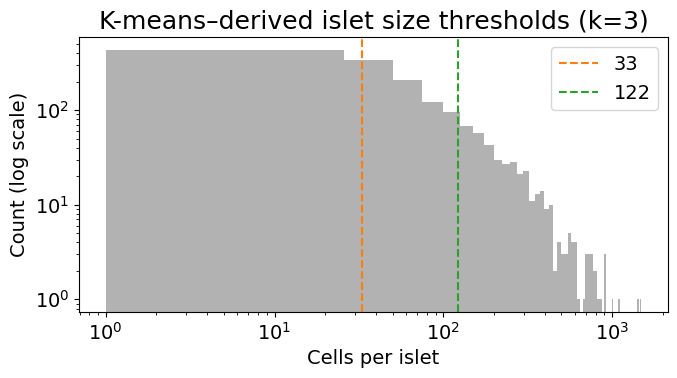

In [6]:
import numpy as np
import pandas as pd

# Ensure cluster_uid exists
if 'cluster_uid' not in dfc.columns:
    raise ValueError("cluster_uid missing – create it first")

# Count cells per islet
islet_sizes = (
    dfc.groupby('cluster_uid')
       .size()
       .rename('n_cells')
       .reset_index()
)

print(islet_sizes.describe())

from sklearn.cluster import KMeans

# Log-transform sizes
X = np.log10(islet_sizes['n_cells'].values).reshape(-1, 1)

k = 3
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=0
)

islet_sizes['kmeans_label'] = kmeans.fit_predict(X)

# Compute cluster centers in original scale
centers_log = kmeans.cluster_centers_.flatten()
centers = 10 ** centers_log

# Sort clusters by size
order = np.argsort(centers)

label_map = {
    old: new
    for new, old in enumerate(order)
}

islet_sizes['size_class'] = islet_sizes['kmeans_label'].map(label_map)

size_names = {
    0: 'small',
    1: 'medium',
    2: 'large'
}

islet_sizes['size_class_name'] = islet_sizes['size_class'].map(size_names)

print("Cluster centers (cells):")
for i, c in enumerate(sorted(centers)):
    print(f"{size_names[i]:>6}: ~{int(c)} cells")

# Centers in sorted log space
centers_log_sorted = np.sort(centers_log)

# Thresholds between clusters (log space midpoints)
thr1_log = (centers_log_sorted[0] + centers_log_sorted[1]) / 2
thr2_log = (centers_log_sorted[1] + centers_log_sorted[2]) / 2

# Convert back to cell counts
thr1 = int(round(10 ** thr1_log))
thr2 = int(round(10 ** thr2_log))

print("Suggested islet size thresholds:")
print(f"small  < {thr1} cells")
print(f"medium {thr1} – {thr2} cells")
print(f"large  > {thr2} cells")

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.hist(
    islet_sizes['n_cells'],
    bins=60,
    log=True,
    alpha=0.6,
    color='gray'
)

plt.axvline(thr1, color='C1', linestyle='--', label=f'{thr1}')
plt.axvline(thr2, color='C2', linestyle='--', label=f'{thr2}')

plt.xscale('log')
plt.xlabel('Cells per islet')
plt.ylabel('Count (log scale)')
plt.title('K-means–derived islet size thresholds (k=3)')
plt.legend()
plt.tight_layout()
plt.show()


# Article-based clustering (9 bins)

Loads the islet shape analysis CSV and assigns each islet to one of 9 size bins using the equivalent-object (EO) diameter method, normalised to a reference islet area of 170² µm². These bins match standard literature-based islet size categories.

In [7]:
import numpy as np
import pandas as pd

# -------------------------
# Load islet-level CSV
# -------------------------
csv_path = r"D:\Kajsa\Dardel\islet_shape_analysis_with_condition.csv"  # change if needed
islets = pd.read_csv(csv_path)

# -------------------------
# Constants
# -------------------------
UM_PER_PX = 0.176
PX_AREA_UM2 = UM_PER_PX**2
A_REF = 170.0**2  # 28900 µm²
BINS_PER_GROUP = 3

# -------------------------
# EO-style approx cells + raw bin
# -------------------------
if "area_um2" not in islets.columns:
    if "area_px" not in islets.columns:
        raise KeyError("CSV must contain 'area_px' (or 'area_um2').")
    islets["area_um2"] = islets["area_px"] * PX_AREA_UM2

islets["approx_cells"] = islets["area_um2"] / A_REF
islets["islet_bin_raw"] = np.floor(np.log2(np.maximum(islets["approx_cells"], 1e-12))).astype(int)

# -------------------------
# Shift so minimum raw bin becomes 0; then clip to 0..8
# -------------------------
bin_min = int(islets["islet_bin_raw"].min())
islets["bin"] = (islets["islet_bin_raw"] - bin_min).astype(int)
islets["bin"] = np.clip(islets["bin"], 0, 8)

# Small/Medium/Large by equal #bins: 0–2, 3–5, 6–8
islets["bin_block"] = (islets["bin"] // BINS_PER_GROUP).astype(int)
block_names = {0: "Small", 1: "Medium", 2: "Large"}
islets["size3"] = islets["bin_block"].map(block_names).fillna("XL+")

# -------------------------
# Table: one row per shifted bin
# -------------------------
bin_tbl = (
    islets.groupby("bin")
    .agg(
        n_islets=("bin","size"),
        min_area_um2=("area_um2","min"),
        max_area_um2=("area_um2","max"),
        min_area_px=("area_px","min") if "area_px" in islets.columns else ("area_um2","min"),
        max_area_px=("area_px","max") if "area_px" in islets.columns else ("area_um2","max"),
        min_approx_cells=("approx_cells","min"),
        max_approx_cells=("approx_cells","max"),
        size_group=("size3", lambda x: x.iloc[0]),
        raw_bin_min=("islet_bin_raw","min"),
        raw_bin_max=("islet_bin_raw","max"),
    )
    .reset_index()
    .sort_values("bin")
)

bin_tbl["area_range_um2"] = bin_tbl.apply(lambda r: f"{r['min_area_um2']:.0f}–{r['max_area_um2']:.0f}", axis=1)
bin_tbl["approx_cells_range"] = bin_tbl.apply(lambda r: f"{r['min_approx_cells']:.2f}–{r['max_approx_cells']:.2f}", axis=1)

final_tbl = bin_tbl[[
    "size_group", "bin", "n_islets", "area_range_um2", "approx_cells_range",
    "raw_bin_min", "raw_bin_max"
]].rename(columns={
    "bin": "Bin (shifted, clipped 0–8)",
    "n_islets": "# islets",
    "area_range_um2": "Min/max area (µm²)",
    "approx_cells_range": "Min/max approx cells",
    "raw_bin_min": "Raw bin",
    "raw_bin_max": "Raw bin (max)"
})

print("Shifted bin mapping:")
print(f"raw_bin_min = {bin_min}  -> shifted Bin 0")
print("Groups by bins:")
print("Small:  bins 0–2")
print("Medium: bins 3–5")
print("Large:  bins 6–8")
print("(Anything above raw bins is clipped into bin 8)")
display(final_tbl)

# -------------------------
# Thresholds: per-bin + group thresholds (in pixels and µm²)
# -------------------------
def _upper_boundary_for_shifted_bin_px(b: int) -> float:
    """
    Upper boundary (exclusive) for shifted bin b (based on EO formula),
    BEFORE clipping effects.
    Uses raw_k = bin_min + b
    Boundary occurs at approx_cells = 2^(raw_k+1)
    """
    raw_k = bin_min + b
    approx_cells_boundary = 2 ** (raw_k + 1)
    area_um2_boundary = approx_cells_boundary * A_REF
    area_px_boundary = area_um2_boundary / PX_AREA_UM2
    return area_px_boundary

# Per-bin upper boundaries for bin_0..bin_7 (bin_8 is clipped top)
bin_edges = []
for b in range(0, 9):
    if b < 8:
        up_px = _upper_boundary_for_shifted_bin_px(b)
        up_um2 = up_px * PX_AREA_UM2
        bin_edges.append({"bin": f"bin_{b}", "upper_px": up_px, "upper_um2": up_um2})
    else:
        bin_edges.append({"bin": "bin_8", "upper_px": np.inf, "upper_um2": np.inf})

bin_edges_df = pd.DataFrame(bin_edges)

# Group thresholds (exactly the ones used in your plots)
thr_small_to_medium_px = _upper_boundary_for_shifted_bin_px(2)  # after bin_2
thr_medium_to_large_px = _upper_boundary_for_shifted_bin_px(5)  # after bin_5

print("\nPer-bin upper thresholds (area_px):")
for _, r in bin_edges_df.iterrows():
    if np.isinf(r["upper_px"]):
        print(f"{r['bin']}: < ∞ (clipped)")
    else:
        print(f"{r['bin']}: < {r['upper_px']:,.0f} px²")

# If you want the thresholds table too:
# display(bin_edges_df)


Shifted bin mapping:
raw_bin_min = -6  -> shifted Bin 0
Groups by bins:
Small:  bins 0–2
Medium: bins 3–5
Large:  bins 6–8
(Anything above raw bins is clipped into bin 8)


,size_group,"Bin (shifted, clipped 0–8)",# islets,Min/max area (µm²),Min/max approx cells,Raw bin,Raw bin (max)
0,Small,0,118,621–902,0.02–0.03,-6,-6
1,Small,1,454,911–1800,0.03–0.06,-5,-5
2,Small,2,415,1810–3608,0.06–0.12,-4,-4
3,Medium,3,387,3620–7200,0.13–0.25,-3,-3
4,Medium,4,301,7240–14440,0.25–0.50,-2,-2
5,Medium,5,172,14458–28875,0.50–1.00,-1,-1
6,Large,6,67,29045–57372,1.01–1.99,0,0
7,Large,7,9,58031–82002,2.01–2.84,1,1
8,Large,8,1,120439–120439,4.17–4.17,2,2



Per-bin upper thresholds (area_px):
bin_0: < 29,156 px²
bin_1: < 58,311 px²
bin_2: < 116,623 px²
bin_3: < 233,245 px²
bin_4: < 466,490 px²
bin_5: < 932,980 px²
bin_6: < 1,865,961 px²
bin_7: < 3,731,921 px²
bin_8: < ∞ (clipped)


# Cluster-size distribution histogram (binned)

Plots the islet size distribution as a histogram on a log x-axis, showing both the 9 EO bins and the three grouped size categories (Small / Medium / Large). EO bin thresholds are recomputed from the islet shape analysis CSV.

In [8]:
# -------------------------
# Plot: Islet size distribution using EO bins (0–8) and Small/Medium/Large (LOG X)
# - Uses islet-level CSV: islet_shape_analysis_with_condition.csv
# - Uses area_px from that CSV as the islet/cluster area (px²)
# - Recomputes EO bin thresholds from THIS CSV (bin_min depends on data)
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load islet-level CSV
# -------------------------
csv_path = r"D:\Kajsa\Dardel\islet_shape_analysis_with_condition.csv"
islets = pd.read_csv(csv_path)

# -------------------------
# Constants
# -------------------------
UM_PER_PX = 0.176
PX_AREA_UM2 = UM_PER_PX**2
A_REF = 170.0**2  # 28900 µm²
BINS_PER_GROUP = 3

# -------------------------
# Pick area column from CSV
# -------------------------
if "area_px" not in islets.columns:
    raise KeyError(f"CSV missing 'area_px'. Columns: {list(islets.columns)[:60]}")

islets["cluster_area_px"] = pd.to_numeric(islets["area_px"], errors="coerce")
islets = islets.dropna(subset=["cluster_area_px"]).copy()
islets = islets[islets["cluster_area_px"] > 0].copy()

if islets.empty:
    raise RuntimeError("No valid area_px > 0 in islet CSV.")

# -------------------------
# EO-style approx cells + raw bin (same logic as your table)
# -------------------------
islets["area_um2"] = islets["cluster_area_px"] * PX_AREA_UM2
islets["approx_cells"] = islets["area_um2"] / A_REF
islets["islet_bin_raw"] = np.floor(np.log2(np.maximum(islets["approx_cells"], 1e-12))).astype(int)

# Shift so min raw bin becomes 0; clip to 0..8
bin_min = int(islets["islet_bin_raw"].min())
islets["bin"] = (islets["islet_bin_raw"] - bin_min).astype(int)
islets["bin"] = np.clip(islets["bin"], 0, 8)

# Small/Medium/Large by equal #bins: 0–2, 3–5, 6–8
islets["bin_block"] = (islets["bin"] // BINS_PER_GROUP).astype(int)
block_names = {0: "Small", 1: "Medium", 2: "Large"}
islets["size3"] = islets["bin_block"].map(block_names).fillna("XL+")

# -------------------------
# Thresholds: per-bin + group thresholds (px²)
# -------------------------
def _upper_boundary_for_shifted_bin_px(b: int) -> float:
    raw_k = bin_min + b
    approx_cells_boundary = 2 ** (raw_k + 1)
    area_um2_boundary = approx_cells_boundary * A_REF
    area_px_boundary = area_um2_boundary / PX_AREA_UM2
    return area_px_boundary

# Per-bin upper boundaries for bin_0..bin_7 (bin_8 is clipped top)
bin_edges = []
for b in range(0, 9):
    if b < 8:
        up_px = _upper_boundary_for_shifted_bin_px(b)
        bin_edges.append({"bin": f"bin_{b}", "upper_px": up_px})
    else:
        bin_edges.append({"bin": "bin_8", "upper_px": np.inf})

bin_edges_df = pd.DataFrame(bin_edges)

thr_small_to_medium_px = _upper_boundary_for_shifted_bin_px(2)  # after bin_2
thr_medium_to_large_px = _upper_boundary_for_shifted_bin_px(5)  # after bin_5

print("Using CSV-driven EO thresholds:")


# -------------------------
# Plot histogram (LOG X)
# -------------------------
cluster_area_px = islets["cluster_area_px"].astype(float).values

xmin = max(1.0, float(np.min(cluster_area_px)))
xmax = float(np.max(cluster_area_px))

# Log-spaced histogram bins
hist_bins = np.logspace(np.log10(xmin), np.log10(xmax), 60)

fig, ax = plt.subplots(figsize=(11, 4.8))
counts, hist_edges, _ = ax.hist(
    cluster_area_px,
    bins=hist_bins,
    edgecolor="black",
    color="lightgray"
)

ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ymax = ax.get_ylim()[1]

# Per-bin EO boundaries
for _, r in bin_edges_df.iterrows():
    up = float(r["upper_px"])
    if np.isinf(up):
        continue
    if up < xmin or up > xmax:
        continue

    ax.axvline(up, color="0.35", linestyle=":", linewidth=1.2, alpha=0.9)
    ax.text(
        up, ymax * 0.98, str(r["bin"]),
        rotation=90, ha="center", va="top",
        fontsize=7, color="0.25",
        bbox=dict(boxstyle="round,pad=0.12", facecolor="white", alpha=0.6, edgecolor="none")
    )

# Small/Medium/Large thresholds
t1 = float(thr_small_to_medium_px)
t2 = float(thr_medium_to_large_px)

ax.axvline(t1, color="tab:green", linestyle="--", linewidth=2.6,
           label="Small → Medium (after bin_2)")
ax.axvline(t2, color="tab:purple", linestyle="--", linewidth=2.6,
           label="Medium → Large (after bin_5)")

# Shade regions (start at xmin on log axis)
ax.axvspan(xmin, min(t1, xmax), color="tab:green", alpha=0.08)
ax.axvspan(max(t1, xmin), min(t2, xmax), color="tab:orange", alpha=0.08)
ax.axvspan(max(t2, xmin), xmax, color="tab:red", alpha=0.06)

# Region labels at geometric midpoints
def _gmid(a, b):
    a = max(a, 1e-12)
    b = max(b, 1e-12)
    return 10 ** ((np.log10(a) + np.log10(b)) / 2)

if t1 > xmin:
    ax.text(_gmid(xmin, min(t1, xmax)), ymax * 0.90, "Small",
            ha="center", va="top", fontsize=10, fontweight="bold")
if t2 > t1:
    ax.text(_gmid(max(t1, xmin), min(t2, xmax)), ymax * 0.90, "Medium",
            ha="center", va="top", fontsize=10, fontweight="bold")
if xmax > t2:
    ax.text(_gmid(max(t2, xmin), xmax), ymax * 0.90, "Large",
            ha="center", va="top", fontsize=10, fontweight="bold")

ax.set_xlabel("Islet/cluster area (px²)  [area_px from islet CSV]  (log scale)")
ax.set_ylabel("Number of islets")
ax.set_title("Islet size distribution using EO bins (0–8) and Small / Medium / Large groups (CSV-based)")
ax.tick_params(axis="x", which="both", labelsize=9)
ax.legend()

plt.tight_layout()

out_fname = OUT_DIR / "06_cluster_area_histogram_EO_bins_logx_from_isletCSV.png"
plt.savefig(out_fname, dpi=200)
plt.close()
print("Saved:", out_fname)


Using CSV-driven EO thresholds:
Saved: D:\Kajsa\Dardel\analysis_plots\06_cluster_area_histogram_EO_bins_logx_from_isletCSV.png


In [9]:
# -------------------------
# Plot: Islet size distribution using EO bins (0–8) and Small/Medium/Large (LINEAR X)
# - Uses islet-level CSV: islet_shape_analysis_with_condition.csv
# - Uses area_px from that CSV as the islet/cluster area (px²)
# - Recomputes EO bin thresholds from THIS CSV (bin_min depends on data)
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load islet-level CSV
# -------------------------
csv_path = r"D:\Kajsa\Dardel\islet_shape_analysis_with_condition.csv"
islets = pd.read_csv(csv_path)

# -------------------------
# Constants
# -------------------------
UM_PER_PX = 0.176
PX_AREA_UM2 = UM_PER_PX**2
A_REF = 170.0**2  # 28900 µm²
BINS_PER_GROUP = 10

# -------------------------
# Pick area column from CSV
# -------------------------
if "area_px" not in islets.columns:
    raise KeyError(f"CSV missing 'area_px'. Columns: {list(islets.columns)[:60]}")

islets["cluster_area_px"] = pd.to_numeric(islets["area_px"], errors="coerce")
islets = islets.dropna(subset=["cluster_area_px"]).copy()
islets = islets[islets["cluster_area_px"] > 0].copy()
if islets.empty:
    raise RuntimeError("No valid area_px > 0 in islet CSV.")

# -------------------------
# EO-style approx cells + raw bin (same logic as your table)
# -------------------------
islets["area_um2"] = islets["cluster_area_px"] * PX_AREA_UM2
islets["approx_cells"] = islets["area_um2"] / A_REF
islets["islet_bin_raw"] = np.floor(np.log2(np.maximum(islets["approx_cells"], 1e-12))).astype(int)

bin_min = int(islets["islet_bin_raw"].min())
islets["bin"] = (islets["islet_bin_raw"] - bin_min).astype(int)
islets["bin"] = np.clip(islets["bin"], 0, 8)

islets["bin_block"] = (islets["bin"] // BINS_PER_GROUP).astype(int)
block_names = {0: "Small", 1: "Medium", 2: "Large"}
islets["size3"] = islets["bin_block"].map(block_names).fillna("XL+")

# -------------------------
# Thresholds: per-bin + group thresholds (px²)
# -------------------------
def _upper_boundary_for_shifted_bin_px(b: int) -> float:
    raw_k = bin_min + b
    approx_cells_boundary = 2 ** (raw_k + 1)
    area_um2_boundary = approx_cells_boundary * A_REF
    area_px_boundary = area_um2_boundary / PX_AREA_UM2
    return area_px_boundary

bin_edges = []
for b in range(0, 9):
    if b < 8:
        up_px = _upper_boundary_for_shifted_bin_px(b)
        bin_edges.append({"bin": f"bin_{b}", "upper_px": up_px})
    else:
        bin_edges.append({"bin": "bin_8", "upper_px": np.inf})
bin_edges_df = pd.DataFrame(bin_edges)

thr_small_to_medium_px = _upper_boundary_for_shifted_bin_px(2)  # after bin_2
thr_medium_to_large_px = _upper_boundary_for_shifted_bin_px(5)  # after bin_5

# -------------------------
# Plot histogram (LINEAR X)
# -------------------------
cluster_area_px = islets["cluster_area_px"].astype(float).values
xmin = 0.0
xmax = float(np.max(cluster_area_px))

# Choose a reasonable linear bin width automatically
# (feel free to override BIN_W if you want)
N_BINS = 120   # try 80–150; 120 works well
hist_bins = np.linspace(0, xmax, N_BINS + 1)

fig, ax = plt.subplots(figsize=(11, 4.8))
counts, hist_edges, _ = ax.hist(
    cluster_area_px,
    bins=hist_bins,
    edgecolor="black",
    color="lightgray"
)

ymax = ax.get_ylim()[1]

# Per-bin EO boundaries
for _, r in bin_edges_df.iterrows():
    up = float(r["upper_px"])
    if np.isinf(up):
        continue
    if up < xmin or up > xmax:
        continue

    ax.axvline(up, color="0.35", linestyle=":", linewidth=1.1, alpha=0.85)
    ax.text(
        up, ymax * 0.98, str(r["bin"]),
        rotation=90, ha="center", va="top",
        fontsize=7, color="0.25",
        bbox=dict(boxstyle="round,pad=0.12", facecolor="white", alpha=0.6, edgecolor="none")
    )

# Small/Medium/Large thresholds
t1 = float(thr_small_to_medium_px)
t2 = float(thr_medium_to_large_px)

# Shade regions
ax.axvspan(0, min(t1, xmax), color="tab:green", alpha=0.08)
ax.axvspan(max(t1, 0), min(t2, xmax), color="tab:orange", alpha=0.08)
ax.axvspan(max(t2, 0), xmax, color="tab:red", alpha=0.06)

# Region labels (linear midpoints)
if t1 > 0:
    ax.text(t1 / 2, ymax * 0.90, "Small", ha="center", va="top", fontsize=10, fontweight="bold")
if t2 > t1:
    ax.text((t1 + t2) / 2, ymax * 0.90, "Medium", ha="center", va="top", fontsize=10, fontweight="bold")
if xmax > t2:
    ax.text((t2 + xmax) / 2, ymax * 0.90, "Large", ha="center", va="top", fontsize=10, fontweight="bold")

# Labels
ax.set_xlabel("Islet/cluster area (px²)  [area_px from islet CSV]")
ax.set_ylabel("Number of islets")
ax.set_title("Islet size distribution using EO bins (0–8) and Small / Medium / Large groups (linear)")

# Make ticks readable (don’t show every histogram edge)
xt = np.linspace(0, xmax, 7)
ax.set_xticks(xt)

ax.legend()
plt.tight_layout()

out_fname = OUT_DIR / "06_cluster_area_histogram_EO_bins_linear_from_isletCSV.png"
plt.savefig(out_fname, dpi=200)
plt.close()
print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\06_cluster_area_histogram_EO_bins_linear_from_isletCSV.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2675056419.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Needs: islets["bin"] already computed (0..8)
x = islets["bin"].astype(float).values

# Try to use SciPy KDE if available; otherwise fallback below
try:
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(x)
    xs = np.linspace(-0.5, 8.5, 400)
    ys = kde(xs)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(xs, ys, linewidth=2)

except Exception:
    # Fallback: smooth histogram (no scipy)
    counts, edges = np.histogram(x, bins=np.arange(-0.5, 9.5, 1), density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    # simple moving-average smoothing
    w = 3
    ys = np.convolve(counts, np.ones(w)/w, mode="same")
    xs = centers

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(xs, ys, linewidth=2)

# ---- Add vertical lines for Small/Medium/Large boundaries in BIN space ----
# small: 0-2, medium: 3-5, large: 6-8 => boundaries at 2.5 and 5.5 visually
ax.axvline(2.5, linestyle="--", linewidth=1.5)
ax.axvline(5.5, linestyle="--", linewidth=1.5)

ax.set_xlabel("Islet size (bins)")
ax.set_ylabel("Density")
ax.set_title("Islet size distribution (EO shifted bins 0–8)")

ax.set_xlim(-0.5, 8.5)
ax.set_xticks(range(0, 9))
plt.tight_layout()

out_fname = OUT_DIR / "07_islet_size_density_bins.png"
plt.savefig(out_fname, dpi=200)
plt.close()
print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\07_islet_size_density_bins.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# EO bins per islet (e.g. islets["bin"])
x = islets["bin"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    x,
    bins=np.arange(-0.5, 9.5, 1),  # bins centered on integers 0–8
    density=True,
    edgecolor="black",
    color="lightgray"
)

ax.set_xlabel("Islet size (EO bin)")
ax.set_ylabel("Density")
ax.set_title("Islet size distribution")

plt.tight_layout()

out_fname = OUT_DIR / "07_islet_size_density_histogram_bins.png"
plt.savefig(out_fname, dpi=200)
plt.close()
print("Saved:", out_fname)

Saved: D:\Kajsa\Dardel\analysis_plots\07_islet_size_density_histogram_bins.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = islets["bin"].astype(float).values

counts, edges = np.histogram(x, bins=np.arange(-0.5, 9.5, 1), density=True)
centers = (edges[:-1] + edges[1:]) / 2

# stronger smoothing
w = 5
ys = np.convolve(counts, np.ones(w)/w, mode="same")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(centers, ys, linewidth=2)

ax.axvline(2.5, linestyle="--", linewidth=1.5)
ax.axvline(5.5, linestyle="--", linewidth=1.5)

ax.set_xlabel("Islet size (bins)")
ax.set_ylabel("Density")
ax.set_title("Islet size distribution (smoothed histogram)")

ax.set_xlim(-0.5, 8.5)
ax.set_xticks(range(0, 9))
plt.tight_layout()

out_fname = OUT_DIR / "07_islet_size_density_bins_smoothed.png"
plt.savefig(out_fname, dpi=200)
plt.close()
print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\07_islet_size_density_bins_smoothed.png


# Islet-level boxplots per condition, stratified by islet size (small/medium/large)

Plots islet cell-type composition stratified into three size groups (Small, Medium, Large) using EO-bin pixel-area thresholds. Produces one PNG per condition, with three boxes (one per size group) for each cell type.

In [13]:
# -------------------------
# Plot 10: Islet-level boxplots per condition, stratified by islet size (small/medium/large)
# - One PNG per condition
# - For each cell type, show three boxes (small, medium, large). Each point = an islet/cluster
# - Size is defined by EO-bin pixel-area thresholds using cluster_area_px = sum(area_cell_px)
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

# Ensure Cell type exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# Ensure cluster_uid exists (you already have it, but keep safe)
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

# -------------------------
# Require pixel thresholds from EO-bin block logic
# -------------------------
if not (('thr_small_to_medium_px' in globals()) and ('thr_medium_to_large_px' in globals())):
    raise NameError("Missing thr_small_to_medium_px / thr_medium_to_large_px. Run the EO-bin pixel-threshold cell first.")

t_px1 = float(thr_small_to_medium_px)
t_px2 = float(thr_medium_to_large_px)

# -------------------------
# Prepare cluster-level percentages
# -------------------------
cluster_counts = dfc.groupby(['cluster_uid', 'Cell type']).size().unstack(fill_value=0)
cluster_counts = cluster_counts.reindex(columns=selected_groups, fill_value=0)
cluster_pct = cluster_counts.div(cluster_counts.sum(axis=1).replace(0, 1), axis=0) * 100

# -------------------------
# NEW: cluster area (pixels) from per-cell area in dfc
# -------------------------
AREA_CELL_COL = "area_cell_px"
if AREA_CELL_COL not in dfc.columns:
    raise KeyError(f"dfc missing '{AREA_CELL_COL}'. Available columns: {list(dfc.columns)[:60]}")

cluster_area_px = dfc.groupby("cluster_uid")[AREA_CELL_COL].sum().astype(float)

def _bin_size_px(area_px):
    if area_px < t_px1:
        return "small"
    elif area_px < t_px2:
        return "medium"
    else:
        return "large"

size_bins_all = cluster_area_px.apply(_bin_size_px)

# -------------------------
# Determine groups (conditions)
# -------------------------
use_meta = ('donor_meta_df' in globals()) and (donor_meta_df is not None) and ('Disease group' in donor_meta_df.columns)

if use_meta:
    donor_key_dfc = _pick_key(dfc, ['donor_base', 'donor', 'Donor'], 'donor (dfc)')
    donor_key_meta = _pick_key(donor_meta_df, ['donor_base', 'donor', 'Donor'], 'donor (donor_meta_df)')

    present_groups = [g for g in desired_order if g in donor_meta_df['Disease group'].values]
    for g in donor_meta_df['Disease group'].dropna().unique():
        if g not in present_groups:
            present_groups.append(g)

    if 'reorder_present_groups' in globals():
        present_groups = reorder_present_groups(present_groups)
else:
    present_groups = ['all']
    donor_key_dfc = None
    donor_key_meta = None

saved_files = []
# -------------------------
# Condition → filename suffix
# -------------------------
COND_FILENAME_MAP = {
    'BMI <30': 'ND - Lean',
    'BMI >30': 'ND - Obese',
    'T1D': 'T1D',
    'T2D': 'T2D',
    'Pre-diabetes': 'Pre_diabetes',
    'BMI_unknown': 'BMI_unknown',
    'none': 'none',
    'all': 'all',
}

for grp in present_groups:
    # pick clusters for this condition
    if grp == 'all' or not use_meta:
        clusters = cluster_counts.index.tolist()
    else:
        donors_in_group = donor_meta_df.loc[donor_meta_df['Disease group'] == grp, donor_key_meta].astype(str).tolist()
        clusters = dfc.loc[dfc[donor_key_dfc].astype(str).isin(donors_in_group), 'cluster_uid'].unique().tolist()

    clusters = [c for c in clusters if c in cluster_counts.index]
    if len(clusters) == 0:
        print(f"Skipping group {grp}: no clusters found")
        continue

    size_bins_grp = size_bins_all.loc[size_bins_all.index.intersection(clusters)]

    # Build long-form table: cluster_uid x size_bin x cell_type x value
    rows = []
    for c in clusters:
        if c not in size_bins_grp.index:
            continue
        bin_label = size_bins_grp.at[c]
        for ct in selected_groups:
            val = cluster_pct.at[c, ct] if ct in cluster_pct.columns else np.nan
            rows.append({'cluster_uid': c, 'size_bin': bin_label, 'cell_type': ct, 'value': val})

    df_plot = pd.DataFrame(rows)
    if df_plot.empty:
        print(f"Skipping group {grp}: no data to plot")
        continue

    # grouped boxplot positions
    size_labels = ['small', 'medium', 'large']
    n_types = len(selected_groups)
    n_sizes = len(size_labels)
    width = 0.18
    gap = 0.45
    base_positions = np.arange(n_types) * (n_sizes * width + gap)

    positions, data_to_plot, colors_list = [], [], []
    for i, ct in enumerate(selected_groups):
        for j, size_label in enumerate(size_labels):
            vals = df_plot.loc[
                (df_plot['cell_type'] == ct) & (df_plot['size_bin'] == size_label),
                'value'
            ].dropna().values
            data_to_plot.append(vals)

            pos = base_positions[i] + (j - (n_sizes - 1) / 2.0) * width
            positions.append(pos)
            colors_list.append(colors[ct])

    fig_w = max(8, n_types * 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(data_to_plot, positions=positions, widths=width * 0.9, patch_artist=True, showfliers=False)
    for patch, col in zip(bp['boxes'], colors_list):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)

    # overlay points
    rng = np.random.RandomState(5)
    for k, arr in enumerate(data_to_plot):
        if arr.size == 0:
            continue
        x = rng.normal(positions[k], width * 0.08, size=arr.size)
        ax.scatter(x, arr, color='k', alpha=0.5, s=5)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(selected_groups, rotation=0, fontsize=10)

    order_text = 'Order per cell: small | medium | large (left→right)'
    cutoffs_text = f'Cutoffs (cluster area_px): small < {t_px1:,.0f}; medium < {t_px2:,.0f}; large ≥ {t_px2:,.0f}'
    ax.text(0.99, 0.98, order_text, ha='right', va='top', transform=ax.transAxes, fontsize=8)
    ax.text(0.99, 0.92, cutoffs_text, ha='right', va='top', transform=ax.transAxes, fontsize=8)

    # stats block unchanged (kept out here for brevity) — your existing stats code can remain
    # -------------------------
    # Stats: pairwise Mann–Whitney between size bins within each cell type
    # Bonferroni across all tests in THIS figure
    # -------------------------
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations

        def p_to_stars(p):
            if p < 1e-4: return '****'
            if p < 1e-3: return '***'
            if p < 1e-2: return '**'
            if p < 0.05: return '*'
            return ''

        # Map (cell_type, size_label) -> (position, values)
        pos_map = {}
        val_map = {}
        idx = 0
        for i, ct in enumerate(selected_groups):
            for j, size_label in enumerate(size_labels):
                pos_map[(ct, size_label)] = positions[idx]
                val_map[(ct, size_label)] = data_to_plot[idx]
                idx += 1

        # Build all comparisons that have >=2 points in both groups
        comps = []
        for ct in selected_groups:
            for a, b in combinations(size_labels, 2):
                va = val_map[(ct, a)]
                vb = val_map[(ct, b)]
                if va is None or vb is None:
                    continue
                if len(va) < 2 or len(vb) < 2:
                    continue
                stat, p = mannwhitneyu(va, vb, alternative='two-sided')
                comps.append((ct, a, b, p))

        n_tests = len(comps)

        # Stack significance bars per cell type separately
        y_levels = {ct: None for ct in selected_groups}

        for ct, a, b, p in comps:
            p_adj = min(p * n_tests, 1.0) if n_tests > 0 else p
            stars = p_to_stars(p_adj)
            if not stars:
                continue

            va = val_map[(ct, a)]
            vb = val_map[(ct, b)]

            base_y = max(
                float(np.max(va)) if len(va) else 0.0,
                float(np.max(vb)) if len(vb) else 0.0
            )

            # place above current highest bar for this cell type
            if y_levels[ct] is None or y_levels[ct] < base_y + 6:
                y = base_y + 6
            else:
                y = y_levels[ct] + 4
            y_levels[ct] = y

            x1 = pos_map[(ct, a)]
            x2 = pos_map[(ct, b)]

            ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
            ax.text((x1 + x2) / 2.0, y + 0.3, stars,
                    ha='center', va='bottom', fontsize=9)

    except Exception as e:
        print("Skipping stats (error):", e)

    ax.set_ylabel('Abundance (%)')
    ax.set_ylim(0, 140)
    try:
        yt = ax.get_yticks()
        ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
    except Exception:
        pass
    ax.set_title(f'Islet-level % abundance by size — condition {grp}')
    plt.tight_layout()

    suffix = COND_FILENAME_MAP.get(grp, _sanitize_name(grp))
    out_fname = OUT_DIR / f"08_islet_abundance_{suffix}.png"

    plt.savefig(out_fname, dpi=200)
    plt.close()

    saved_files.append(str(out_fname))


if saved_files:
    print('Saved islet-level size-stratified plots:\n' + '\n'.join(saved_files))
else:
    print('No islet-level plots created.')


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2667169969.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2667169969.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2667169969.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2667169969.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set

Saved islet-level size-stratified plots:
D:\Kajsa\Dardel\analysis_plots\08_islet_abundance_T1D.png
D:\Kajsa\Dardel\analysis_plots\08_islet_abundance_T2D.png
D:\Kajsa\Dardel\analysis_plots\08_islet_abundance_Pre_diabetes.png
D:\Kajsa\Dardel\analysis_plots\08_islet_abundance_ND_-_Obese.png
D:\Kajsa\Dardel\analysis_plots\08_islet_abundance_ND_-_Lean.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\2667169969.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


# Islet-level boxplots per condition, stratified by islet size (/bins)

Same as the previous section but uses all 9 EO bins individually instead of collapsing them into three size groups. Produces one PNG per condition with 9 boxes per cell type.

In [14]:
# -------------------------
# Plot 10 (BIN VERSION): Islet-level boxplots per condition, stratified by EO bin (bin_0..bin_8)
# - One PNG per condition
# - For each cell type, show 9 boxes (bin_0..bin_8). Each point = an islet/cluster
# - Bin assignment uses the SAME EO bin thresholds you computed earlier
#   (bin_edges_df with upper_px for bin_0..bin_7; bin_8 is >= upper(bin_7))
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- Ensure donor_base exists in dfc (needed for donor_meta_df grouping) ---
if "donor_base" not in dfc.columns:
    if "image_stem" in dfc.columns:
        # ROI_1535_F1_disp_thr_4ch.ome  -> donor_base = F1
        dfc["donor_base"] = (
            dfc["image_stem"].astype(str)
            .str.extract(r"ROI[_\-\s]*\d+[_\-\s]*([^_\-\s]+)", expand=False)
        )
    else:
        raise KeyError("dfc has no donor_base and no image_stem to extract it from.")

# (optional) strip Donor_ prefix if it ever appears
dfc["donor_base"] = dfc["donor_base"].astype(str).str.replace(r"^Donor_", "", regex=True).str.strip()


try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

# Ensure Cell type exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# Ensure cluster_uid exists
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

# -------------------------
# Require per-bin thresholds (bin_edges_df) from your combined EO-bin cell
# -------------------------
if "bin_edges_df" not in globals():
    raise NameError("Missing bin_edges_df (per-bin thresholds). Run the combined EO-bin thresholds cell first.")

# Expect bin_edges_df columns: bin (like 'bin_0'), upper_px (float; bin_8 = inf)
_tmp = bin_edges_df.copy()
if "upper_px" not in _tmp.columns:
    raise KeyError("bin_edges_df must contain column 'upper_px'.")

# Build sorted list of upper edges for bins 0..7 (bin_8 is inf)
# We'll use these edges to assign bins with np.digitize
upper_edges_0_7 = []
for i in range(0, 8):
    row = _tmp.loc[_tmp["bin"] == f"bin_{i}"]
    if row.empty:
        raise KeyError(f"bin_edges_df missing row for bin_{i}.")
    upper_edges_0_7.append(float(row["upper_px"].iloc[0]))

upper_edges_0_7 = np.array(upper_edges_0_7, dtype=float)  # length 8 (bin0..bin7 upper bounds)

# -------------------------
# Prepare cluster-level percentages
# -------------------------
cluster_counts = dfc.groupby(['cluster_uid', 'Cell type']).size().unstack(fill_value=0)
cluster_counts = cluster_counts.reindex(columns=selected_groups, fill_value=0)
cluster_pct = cluster_counts.div(cluster_counts.sum(axis=1).replace(0, 1), axis=0) * 100

AREA_CELL_COL = "area_cell_px"
if AREA_CELL_COL not in dfc.columns:
    raise KeyError(f"dfc missing '{AREA_CELL_COL}' (needed for area-based size bins).")

cluster_area_px = (
    dfc.groupby("cluster_uid")[AREA_CELL_COL]
       .sum()
       .astype(float)
)
# -------------------------
# Cluster area (pixels) from per-cell area in dfc
# -------------------------
AREA_CELL_COL = "area_cell_px"
if AREA_CELL_COL not in dfc.columns:
    raise KeyError(f"dfc missing '{AREA_CELL_COL}'. Available columns: {list(dfc.columns)[:60]}")

cluster_area_px = dfc.groupby("cluster_uid")[AREA_CELL_COL].sum().astype(float)

# -------------------------
# Assign bin_0..bin_8 for each cluster based on area_px thresholds
# -------------------------
# np.digitize returns 0..len(edges); with edges of length 8:
# area < edge0 -> 0
# edge0 <= area < edge1 -> 1
# ...
# edge7 <= area -> 8  (this is bin_8, the clipped top)
bin_idx = np.digitize(cluster_area_px.values, upper_edges_0_7, right=True)
# right=True gives: area <= edge0 -> bin0; edge0 < area <= edge1 -> bin1 ... (matches "upper threshold" idea)

cluster_to_bin = pd.Series(bin_idx, index=cluster_area_px.index).astype(int).clip(0, 8)
cluster_to_bin_label = cluster_to_bin.map(lambda b: f"bin_{b}")

# -------------------------
# Determine groups (conditions)
# -------------------------
use_meta = ('donor_meta_df' in globals()) and (donor_meta_df is not None) and ('Disease group' in donor_meta_df.columns)

if use_meta:
    donor_key_dfc  = _pick_key(dfc, ['donor_base'], 'donor (dfc)')
    donor_key_meta = _pick_key(donor_meta_df, ['donor_base'], 'donor (donor_meta_df)')

    present_groups = [g for g in desired_order if g in donor_meta_df['Disease group'].values]
    for g in donor_meta_df['Disease group'].dropna().unique():
        if g not in present_groups:
            present_groups.append(g)

    if 'reorder_present_groups' in globals():
        present_groups = reorder_present_groups(present_groups)
else:
    present_groups = ['all']
    donor_key_dfc = None
    donor_key_meta = None

saved_files = []

# -------------------------
# Plot per condition
# -------------------------
bin_labels = [f"bin_{i}" for i in range(0, 9)]  # 9 bins
n_bins = len(bin_labels)

for grp in present_groups:
    # pick clusters for this condition
    if grp == 'all' or not use_meta:
        clusters = cluster_counts.index.tolist()
    else:
        # Normalize donor ids (strip + lower) for robust matching
        donors_in_group_raw = donor_meta_df.loc[donor_meta_df['Disease group'] == grp, donor_key_meta].tolist()
        donors_in_group = [str(x).strip().lower() for x in donors_in_group_raw if pd.notna(x)]

        # Normalize donor column in dfc
        if donor_key_dfc in dfc.columns:
            dfc_donor_norm = dfc[donor_key_dfc].astype(str).str.strip().str.lower()
            clusters = dfc.loc[dfc_donor_norm.isin(donors_in_group), 'cluster_uid'].unique().tolist()
        else:
            clusters = []

        # If we found none, print helpful debug information and try a fallback substring match
        if len(clusters) == 0:
            unique_dfc_donors = dfc[donor_key_dfc].astype(str).str.strip().unique().tolist() if donor_key_dfc in dfc.columns else []
            print(f"[debug] group '{grp}': no clusters found using donor column '{donor_key_dfc}'.")
            print(f"  donors_in_group (n={len(donors_in_group)}): {donors_in_group[:10]}")
            print(f"  unique donors in dfc (n={len(unique_dfc_donors)}): {unique_dfc_donors[:10]}")

            # raw attempts
            donors_in_group_raw_stripped = [str(x).strip() for x in donors_in_group_raw if pd.notna(x)]
            dfc_donor_raw_unique = dfc[donor_key_dfc].astype(str).str.strip().unique().tolist() if donor_key_dfc in dfc.columns else []
            print(f"  (raw) donors_in_group sample: {donors_in_group_raw_stripped[:10]}")
            print(f"  (raw) donors in dfc sample: {dfc_donor_raw_unique[:10]}")

            # fallback: substring matching
            matched = []
            for d in donors_in_group_raw_stripped:
                for dc in dfc_donor_raw_unique:
                    if d.lower() in dc.lower() or dc.lower() in d.lower():
                        matched.append(dc)
            matched = list(dict.fromkeys(matched))  # unique preserve order
            if matched:
                print(f"  fallback matched donor ids in dfc: {matched[:10]}")
                clusters = dfc.loc[dfc[donor_key_dfc].astype(str).str.strip().isin(matched), 'cluster_uid'].unique().tolist()
                print(f"  group '{grp}': found {len(clusters)} clusters via fallback.")
            else:
                print(f"  No fallback matches for group '{grp}'")

    clusters = [c for c in clusters if c in cluster_counts.index]
    if len(clusters) == 0:
        print(f"Skipping group {grp}: no clusters found")
        continue

    # -------------------------
    # Build long-form table: cluster_uid x bin_label x cell_type x value
    # -------------------------
    rows = []
    for c in clusters:
        if c not in cluster_to_bin_label.index:
            continue
        b_label = cluster_to_bin_label.at[c]
        for ct in selected_groups:
            val = cluster_pct.at[c, ct] if ct in cluster_pct.columns else np.nan
            rows.append({'cluster_uid': c, 'bin': b_label, 'cell_type': ct, 'value': val})

    df_plot = pd.DataFrame(rows)
    if df_plot.empty:
        print(f"Skipping group {grp}: no data to plot")
        continue

    # -------------------------
    # grouped boxplot positions: per cell type, 9 bins
    # -------------------------
    n_types = len(selected_groups)
    width = 0.12            # narrower because 9 boxes
    gap = 0.2
    base_positions = np.arange(n_types) * (n_bins * width + gap)

    positions, data_to_plot, colors_list, counts = [], [], [], []

    for i, ct in enumerate(selected_groups):
        for j, b in enumerate(bin_labels):
            vals = df_plot.loc[
                (df_plot['cell_type'] == ct) & (df_plot['bin'] == b),
                'value'
            ].dropna().values

            data_to_plot.append(vals)
            pos = base_positions[i] + (j - (n_bins - 1) / 2.0) * width
            positions.append(pos)
            colors_list.append(colors[ct])
            counts.append(len(vals))

    fig_w = max(12, n_types * 2.4)  # wider due to 9 bins per cell type
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )

    for patch, col in zip(bp['boxes'], colors_list):
        patch.set_facecolor(col)
        patch.set_alpha(0.55)

    # overlay points
    rng = np.random.RandomState(5)
    for k, arr in enumerate(data_to_plot):
        if arr.size == 0:
            continue
        x = rng.normal(positions[k], width * 0.15, size=arr.size)
        ax.scatter(x, arr, color='k', alpha=0.35, s=5)

    # Stats: pairwise Mann-Whitney U per cell type across bins with Bonferroni correction
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations

        comps = []
        for i in range(n_types):
            seg = data_to_plot[i * n_bins:(i + 1) * n_bins]
            valid_idxs = [j for j, arr in enumerate(seg) if len(arr) > 0]
            for a, b in combinations(valid_idxs, 2):
                arr1, arr2 = seg[a], seg[b]
                # require at least 2 observations per group for a stable test
                if len(arr1) < 2 or len(arr2) < 2:
                    continue
                _, p = mannwhitneyu(arr1, arr2, alternative='two-sided')
                comps.append((i, a, b, p))

        n_tests = len(comps)

        def p_to_stars(p):
            if p < 1e-4: return '****'
            if p < 1e-3: return '***'
            if p < 1e-2: return '**'
            if p < 0.05: return '*'
            return ''

        max_y = 0
        if n_tests > 0:
            y_levels = {i: None for i in range(n_types)}
            for i, a, b, p in comps:
                p_adj = min(p * n_tests, 1.0)  # Bonferroni correction
                stars = p_to_stars(p_adj)
                if not stars:
                    continue

                x1 = base_positions[i] + (a - (n_bins - 1) / 2.0) * width
                x2 = base_positions[i] + (b - (n_bins - 1) / 2.0) * width

                seg = data_to_plot[i * n_bins:(i + 1) * n_bins]
                base_y = max((max(seg[a]) if len(seg[a]) else 0),
                             (max(seg[b]) if len(seg[b]) else 0))

                if y_levels[i] is None or y_levels[i] < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_levels[i] + 4
                y_levels[i] = y
                max_y = max(max_y, y + 2)

                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.2, stars, ha='center', va='bottom', fontsize=8)

        # expand y-axis if annotations extend beyond current limit
        if max_y > ax.get_ylim()[1] - 5:
            ax.set_ylim(0, max(max_y + 6, ax.get_ylim()[1]))

    except Exception as e:
        print('Skipping statistical tests (bin plots):', e)

    # x tick labels: show only cell type centers
    ax.set_xticks(base_positions)
    ax.set_xticklabels(selected_groups, rotation=0, fontsize=12)

    # Optional: show bin labels under each cell type (can get busy)
    # Here we print bin order text + group threshold text
    ax.text(0.99, 0.98, "Order per cell: bin_0 … bin_8 (left→right)", ha='right', va='top',
            transform=ax.transAxes, fontsize=8)

    # show the group thresholds (after bin2 and bin5) as pixel boundaries
    t1 = upper_edges_0_7[2]  # upper of bin_2
    t2 = upper_edges_0_7[5]  # upper of bin_5
    ax.text(0.99, 0.92,
            f"Group cutoffs (area_px): after bin_2 < {t1:,.0f}; after bin_5 < {t2:,.0f}; bin_8 is clipped top",
            ha='right', va='top', transform=ax.transAxes, fontsize=8)

    ax.set_ylabel('Abundance (%)')
    ax.set_ylim(0, 170)

    # Hide y-tick labels above 100 but keep the space
    yt = ax.get_yticks()
    ax.set_yticks(yt)  # keep same tick locations
    ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])

    ax.set_title(f'Islet-level % abundance by EO bin — condition {grp}')
    plt.tight_layout()

    suffix = COND_FILENAME_MAP.get(grp, _sanitize_name(grp))
    out_fname = OUT_DIR / f"09_islet_abundance_bins_{suffix}.png"
    plt.savefig(out_fname, dpi=200)
    plt.close()

    saved_files.append(str(out_fname))

if saved_files:
    print('Saved islet-level BIN-stratified plots:', '\n'.join(saved_files))
else:
    print('No islet-level plots created.')


Saved islet-level BIN-stratified plots: D:\Kajsa\Dardel\analysis_plots\09_islet_abundance_bins_T1D.png
D:\Kajsa\Dardel\analysis_plots\09_islet_abundance_bins_T2D.png
D:\Kajsa\Dardel\analysis_plots\09_islet_abundance_bins_Pre_diabetes.png
D:\Kajsa\Dardel\analysis_plots\09_islet_abundance_bins_ND_-_Obese.png
D:\Kajsa\Dardel\analysis_plots\09_islet_abundance_bins_ND_-_Lean.png


# Boxplot of cluster sizes (small/medium/large)

For each EO bin, generates a figure comparing conditions within that bin — one box per condition for each cell type. Applies Mann-Whitney U tests with Bonferroni correction and limits annotations to avoid overlap.

In [15]:
# -------------------------
# Compare CONDITIONS within each BIN (one PNG per bin_0..bin_8)
# - For each bin, one figure:
#   for each cell type: one box per condition
# - Each point = an islet/cluster
# - Stats: Mann-Whitney within each cell type across conditions (Bonferroni)
#   FIX: avoid annotation overlap by plotting only the top N significant comparisons per cell type
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

def _p_to_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return ''

# -------------------------
# Tweak knobs
# -------------------------
YMIN = 0
YMAX_BASE = 140
YSHOW_LABEL_MAX = 100

width = 0.16
gap = 0.30

JITTER = 0.10          # jitter relative to width
POINT_ALPHA = 0.35
POINT_SIZE = 7

# Annotation controls (THIS is the main fix)
MAX_ANN_PER_CELLTYPE = 6    # set None to show all (can get messy)
ANN_STEP = 4.0              # vertical spacing between bars
ANN_PAD = 6.0               # first bar height above max(box data)
ANN_TEXT_DY = 0.2

# -------------------------
# Ensure Cell type
# -------------------------
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# Ensure cluster_uid
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

# Need metadata
use_meta = ('donor_meta_df' in globals()) and (donor_meta_df is not None) and ('Disease group' in donor_meta_df.columns)
if not use_meta:
    raise RuntimeError("Need donor_meta_df with 'Disease group' to compare conditions.")

donor_key_dfc  = _pick_key(dfc, ['donor_base', 'donor', 'Donor'], 'donor (dfc)')
donor_key_meta = _pick_key(donor_meta_df, ['donor_base', 'donor', 'Donor'], 'donor (donor_meta_df)')

# Condition order (and restrict to those present)
present_groups = [g for g in desired_order if g in donor_meta_df['Disease group'].values]
for g in donor_meta_df['Disease group'].dropna().unique():
    if g not in present_groups:
        present_groups.append(g)
if 'reorder_present_groups' in globals():
    present_groups = reorder_present_groups(present_groups)

# -------------------------
# Cluster-level % (one row per cluster)
# -------------------------
cluster_counts = dfc.groupby(['cluster_uid', 'Cell type']).size().unstack(fill_value=0)
cluster_counts = cluster_counts.reindex(columns=selected_groups, fill_value=0)
cluster_pct = cluster_counts.div(cluster_counts.sum(axis=1).replace(0, 1), axis=0) * 100

# -------------------------
# Cluster area (px) and BIN assignment (bin_0..bin_8)
# Requires bin_edges_df (from your combined thresholds cell)
# -------------------------
AREA_CELL_COL = "area_cell_px"
if AREA_CELL_COL not in dfc.columns:
    raise KeyError(f"dfc missing '{AREA_CELL_COL}'")

cluster_area_px = dfc.groupby("cluster_uid")[AREA_CELL_COL].sum().astype(float)

if "bin_edges_df" not in globals():
    raise NameError("Missing bin_edges_df. Run the EO bin threshold cell first.")

upper_edges_0_7 = []
for i in range(0, 8):
    row = bin_edges_df.loc[bin_edges_df["bin"] == f"bin_{i}"]
    if row.empty:
        raise KeyError(f"bin_edges_df missing row for bin_{i}")
    upper_edges_0_7.append(float(row["upper_px"].iloc[0]))
upper_edges_0_7 = np.array(upper_edges_0_7, dtype=float)

bin_idx = np.digitize(cluster_area_px.values, upper_edges_0_7, right=True)
cluster_bin = pd.Series(bin_idx, index=cluster_area_px.index).astype(int).clip(0, 8)
cluster_bin_label = cluster_bin.map(lambda b: f"bin_{b}")

# -------------------------
# Map cluster -> condition
# -------------------------
donor_to_group = donor_meta_df.set_index(donor_key_meta)['Disease group'].to_dict()
cluster_to_donor = dfc.groupby("cluster_uid")[donor_key_dfc].first().astype(str).to_dict()
cluster_to_group = {c: donor_to_group.get(d, 'none') for c, d in cluster_to_donor.items()}

# -------------------------
# Build one LONG dataframe: one row per (cluster, celltype)
# -------------------------
rows = []
for c in cluster_pct.index:
    grp = cluster_to_group.get(c, 'none')
    b = cluster_bin_label.get(c, None)
    if b is None:
        continue
    for ct in selected_groups:
        rows.append({
            "cluster_uid": c,
            "condition": grp,
            "bin": b,
            "cell_type": ct,
            "value": float(cluster_pct.at[c, ct]) if ct in cluster_pct.columns else np.nan
        })

df_long = pd.DataFrame(rows).dropna(subset=["value"])
if df_long.empty:
    raise RuntimeError("df_long is empty. Nothing to plot.")

# -------------------------
# Plot: one figure per BIN, compare conditions within cell types
# -------------------------
bin_labels = [f"bin_{i}" for i in range(0, 9)]
n_types = len(selected_groups)
n_groups = len(present_groups)

# stats imports
try:
    from scipy.stats import mannwhitneyu
    from itertools import combinations
    HAVE_STATS = True
except Exception as e:
    print("Stats disabled (missing scipy?):", e)
    HAVE_STATS = False

for b in bin_labels:
    sub = df_long[df_long["bin"] == b].copy()
    if sub.empty:
        print(f"[skip] {b}: no clusters")
        continue

    base_positions = np.arange(n_types) * (n_groups * width + gap)

    positions, data_to_plot, box_cols, counts = [], [], [], []

    for i, ct in enumerate(selected_groups):
        for j, grp in enumerate(present_groups):
            vals = sub.loc[(sub["cell_type"] == ct) & (sub["condition"] == grp), "value"].values
            data_to_plot.append(vals)

            pos = base_positions[i] + (j - (n_groups - 1) / 2.0) * width
            positions.append(pos)

            box_cols.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    fig_w = max(10, 1.2 * n_types + 0.9 * n_groups)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )
    for box, col in zip(bp["boxes"], box_cols):
        box.set_facecolor(col)
        box.set_alpha(0.80)
        box.set_edgecolor("k")

    # overlay points
    rng = np.random.RandomState(7)
    for k, arr in enumerate(data_to_plot):
        if len(arr) == 0:
            continue
        xs = rng.normal(positions[k], width * JITTER, size=len(arr))
        ax.scatter(xs, arr, color="k", alpha=POINT_ALPHA, s=POINT_SIZE, zorder=3)

    # ---- Stats + annotations (limited per cell type to avoid overwriting) ----
    max_y_used = YMAX_BASE

    if HAVE_STATS:
        for i in range(n_types):
            seg = data_to_plot[i * n_groups:(i + 1) * n_groups]

            valid = [j for j, arr in enumerate(seg) if len(arr) >= 2]
            if len(valid) < 2:
                continue

            # all comparisons for this cell type
            comps = []
            for a, c2 in combinations(valid, 2):
                try:
                    _, p = mannwhitneyu(seg[a], seg[c2], alternative="two-sided")
                    comps.append((a, c2, float(p)))
                except Exception:
                    continue

            if not comps:
                continue

            # Bonferroni within THIS cell type (less brutal than across all types)
            n_tests = len(comps)
            comps2 = []
            for a, c2, p in comps:
                p_adj = min(p * n_tests, 1.0)
                stars = _p_to_stars(p_adj)
                if stars:
                    comps2.append((a, c2, p_adj, stars))

            if not comps2:
                continue

            # keep only top N (smallest p_adj) to avoid clutter
            comps2.sort(key=lambda t: t[2])  # by p_adj
            if MAX_ANN_PER_CELLTYPE is not None:
                comps2 = comps2[:MAX_ANN_PER_CELLTYPE]

            # start height above max data in this cell-type block
            base_y = 0.0
            for j in valid:
                if len(seg[j]) > 0:
                    base_y = max(base_y, float(np.max(seg[j])))
            y = base_y + ANN_PAD

            # draw stacked
            for a, c2, p_adj, stars in comps2:
                x1 = base_positions[i] + (a  - (n_groups - 1) / 2.0) * width
                x2 = base_positions[i] + (c2 - (n_groups - 1) / 2.0) * width

                ax.plot([x1, x2], [y, y], color="k", linewidth=1.0, zorder=4)
                ax.text((x1 + x2) / 2.0, y + ANN_TEXT_DY, stars,
                        ha="center", va="bottom", fontsize=9, zorder=5)

                y += ANN_STEP
                max_y_used = max(max_y_used, y + 3)

    # formatting
    ax.set_xticks(base_positions)
    ax.set_xticklabels(selected_groups, rotation=0, fontsize=12)
    ax.set_ylabel("Abundance (%)")
    ax.set_title(f"Islet-level % abundance — {b} (compare conditions)")

    ax.set_ylim(YMIN, max(YMAX_BASE, max_y_used))

    # remove y tick labels above 100, keep space
    yt = ax.get_yticks()
    ax.set_yticks(yt)
    ax.set_yticklabels([str(int(y)) if y <= YSHOW_LABEL_MAX else "" for y in yt])

    # counts under each cell type (in condition order)
    count_lines = []
    for i in range(n_types):
        seg = counts[i * n_groups:(i + 1) * n_groups]
        count_lines.append(" / ".join(str(x) for x in seg))
    for xi, txt in zip(base_positions, count_lines):
        ax.text(xi, -0.08, txt, ha="center", va="top", fontsize=7, transform=ax.get_xaxis_transform())

    # legend for condition colors
    try:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Condition")
    except Exception:
        pass

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    out_fname = OUT_DIR / f"10_islet_abundance_compare_conditions_{_sanitize_name(b)}.png"
    plt.savefig(out_fname, dpi=200, bbox_inches="tight")
    plt.close()

    print("Saved:", out_fname)


Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_0.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_1.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_2.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_3.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_4.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_5.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_6.png
Saved: D:\Kajsa\Dardel\analysis_plots\10_islet_abundance_compare_conditions_bin_7.png
[skip] bin_8: no clusters


In [16]:
# -------------------------
# Plot 11–13: Compare small / medium / large islets across conditions
# - For each size class, create one figure where each cell type has one box per condition
# - Each point is one islet/cluster (value = % abundance of that cell-type in that islet)
# -------------------------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# Fallback if not defined elsewhere
def _sanitize_name(s: str) -> str:
    return re.sub(r"[^\w\-_\.]", "_", str(s))

# Ensure Cell type exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# Ensure cluster_uid exists
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = dfc[CLUSTER_COL].astype(int).astype(str)

# Cluster-level % per cell type
cluster_counts = (
    dfc.groupby(['cluster_uid', 'Cell type'])
       .size()
       .unstack(fill_value=0)
       .reindex(columns=selected_groups, fill_value=0)
)
cluster_pct = cluster_counts.div(cluster_counts.sum(axis=1).replace(0, 1), axis=0) * 100

# Determine condition groups
use_meta = ('donor_meta_df' in globals()) and (donor_meta_df is not None) and ('Disease group' in donor_meta_df.columns)

if use_meta:
    donor_key_dfc  = _pick_key(dfc, ['donor_base', 'donor', 'Donor', 'donor_folder'], 'donor (dfc)')
    donor_key_meta = _pick_key(donor_meta_df, ['donor_base', 'donor', 'Donor', 'donor_folder'], 'donor (donor_meta_df)')

    present_groups = [g for g in desired_order if g in donor_meta_df['Disease group'].values]
    for g in donor_meta_df['Disease group'].dropna().unique():
        if g not in present_groups:
            present_groups.append(g)
    present_groups = reorder_present_groups(present_groups)
else:
    present_groups = ['all']
    donor_key_dfc = None
    donor_key_meta = None

thr_low, thr_high = thr_small_to_medium_px, thr_medium_to_large_px  # fixed size thresholds
size_labels = ['small', 'medium', 'large']
saved = []

# Pre-build legend handles once (consistent across all plots)
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g)
    for g in present_groups
]

for size_label in size_labels:
    n_types = len(selected_groups)
    n_groups = len(present_groups)

    width = 0.18
    gap = 0.45
    base_positions = np.arange(n_types) * (n_groups * width + gap)

    positions = []
    data_to_plot = []
    box_colors = []
    counts = []

    # Build (cell_type, condition) arrays
    for i, ct in enumerate(selected_groups):
        for j, grp in enumerate(present_groups):
            if grp == 'all':
                clusters = cluster_counts.index.tolist()
            else:
                donors_in_group = donor_meta_df.loc[donor_meta_df['Disease group'] == grp, donor_key_meta].astype(str).tolist()
                clusters = dfc.loc[dfc[donor_key_dfc].astype(str).isin(donors_in_group), 'cluster_uid'].unique().tolist()


            clusters = [c for c in clusters if c in cluster_counts.index]

            if not clusters:
                vals = np.array([])
            else:
                areas = cluster_area_px.reindex(clusters).dropna()

                bins = {}
                for c, a in areas.items():
                    if a < thr_small_to_medium_px:
                        bins[c] = 'small'
                    elif a < thr_medium_to_large_px:
                        bins[c] = 'medium'
                    else:
                        bins[c] = 'large'


                clusters_in_bin = [c for c, b in bins.items() if b == size_label]
                vals = cluster_pct.loc[cluster_pct.index.intersection(clusters_in_bin), ct].dropna().values

            data_to_plot.append(vals)
            pos = base_positions[i] + (j - (n_groups - 1) / 2.0) * width
            positions.append(pos)
            box_colors.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    if all(len(x) == 0 for x in data_to_plot):
        print(f"Skipping size {size_label}: no data across any condition")
        continue

    # ----- Plot -----
    fig_w = max(10, 1.2 * n_types + 0.35 * n_groups)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )
    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.9)
        patch.set_edgecolor('k')

    # Overlay points
    rng = np.random.RandomState(6)
    for k, arr in enumerate(data_to_plot):
        if len(arr) == 0:
            continue
        xj = rng.normal(positions[k], width * 0.06, size=len(arr))
        ax.scatter(xj, arr, color='k', alpha=0.6, s=18)

    # X labels (horizontal)
    ax.set_xticks(base_positions)
    ax.set_xticklabels(selected_groups, rotation=0, ha='center')

    # Optional: thresholds text (keep or remove)
    cutoffs_text = (
        f"Cutoffs (area_px): small < {thr_small_to_medium_px:,.0f}; "
        f"medium < {thr_medium_to_large_px:,.0f}; large ≥ {thr_medium_to_large_px:,.0f}"
    )

    ax.text(0.99, 0.92, cutoffs_text, ha='right', va='top', transform=ax.transAxes, fontsize=8)

    # Counts under each cell type
    for i, xi in enumerate(base_positions):
        seg = counts[i * n_groups:(i + 1) * n_groups]
        ax.text(
            xi, -8,
            ' / '.join(str(x) for x in seg),
            ha='center', va='top', fontsize=7,
            transform=ax.get_xaxis_transform()
        )

    # Stats annotations (same logic you had)
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations

        comps = []
        for i in range(n_types):
            seg = data_to_plot[i * n_groups:(i + 1) * n_groups]
            valid_idxs = [j for j, arr in enumerate(seg) if len(arr) > 0]
            for a, b in combinations(valid_idxs, 2):
                arr1, arr2 = seg[a], seg[b]
                if len(arr1) < 2 or len(arr2) < 2:
                    continue
                _, p = mannwhitneyu(arr1, arr2, alternative='two-sided')
                comps.append((i, a, b, p))

        n_tests = len(comps)

        def p_to_stars(p):
            if p < 1e-4: return '****'
            if p < 1e-3: return '***'
            if p < 1e-2: return '**'
            if p < 0.05: return '*'
            return ''

        if n_tests > 0:
            y_levels = {i: None for i in range(n_types)}
            for i, a, b, p in comps:
                p_adj = min(p * n_tests, 1.0)
                stars = p_to_stars(p_adj)
                if not stars:
                    continue

                x1 = base_positions[i] + (a - (n_groups - 1) / 2.0) * width
                x2 = base_positions[i] + (b - (n_groups - 1) / 2.0) * width

                seg = data_to_plot[i * n_groups:(i + 1) * n_groups]
                base_y = max((max(seg[a]) if len(seg[a]) else 0),
                             (max(seg[b]) if len(seg[b]) else 0))

                if y_levels[i] is None or y_levels[i] < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_levels[i] + 4
                y_levels[i] = y

                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.2, stars, ha='center', va='bottom', fontsize=9)

    except Exception as e:
        print('Skipping statistical tests:', e)

    ax.set_ylabel('Abundance (%)')
    ax.set_title(f'Islet-level % abundance — size: {size_label}')
    ax.set_ylim(0, 140)
    try:
        yt = ax.get_yticks()
        ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
    except Exception:
        pass

    # Legend outside on the right (consistent)
    ax.legend(
        handles=legend_handles,
        title="Condition",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        frameon=True
    )

    # Move axes LEFT by reserving a right margin for legend
    fig.subplots_adjust(
        left=0.06,
        right=0.80,   # smaller -> more space for legend, axes move left
        bottom=0.16,
        top=0.90
    )

    # Save (IMPORTANT: don't use bbox_inches="tight" here)
    safe = _sanitize_name(size_label)
    out_fname = OUT_DIR / f"11_islet_by_condition_size_{safe}.png"
    plt.savefig(out_fname, dpi=200)
    plt.close()

    saved.append(str(out_fname))
    print("Saved:", out_fname)


if saved:

    print("Saved size comparison plots:\n" + "\n".join(saved))    
else:
    print("No size-comparison plots created.")

C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4090002963.py:221: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_small.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4090002963.py:221: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_medium.png
Saved: D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_large.png
Saved size comparison plots:
D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_small.png
D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_medium.png
D:\Kajsa\Dardel\analysis_plots\11_islet_by_condition_size_large.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4090002963.py:221: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


In [17]:
# -------------------------
# Plot 15: Per CELL TYPE boxplots comparing CONDITIONS across islet sizes (Small/Medium/Large)
# - One PNG per cell type
# - For each condition: three boxes (Small/Medium/Large), each dot = islet/cluster
# - Stats: Mann–Whitney within each condition across sizes, Bonferroni PER CONDITION
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

def p_to_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return ''

# Ensure Cell type exists
if 'Cell type' not in dfc.columns:
    dfc['Cell type'] = dfc[CELLTYPE_COL].apply(map_celltype_to_group)

# Ensure cluster_uid exists
if 'cluster_uid' not in dfc.columns:
    if ROI_COL in dfc.columns:
        dfc['_roi_int'] = pd.to_numeric(dfc[ROI_COL], errors='coerce').fillna(-1).astype(int)
        dfc['_cluster_int'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int)
        dfc['cluster_uid'] = dfc['_cluster_int'].astype(str) + '_R' + dfc['_roi_int'].astype(str)
    else:
        dfc['cluster_uid'] = pd.to_numeric(dfc[CLUSTER_COL], errors='coerce').fillna(0).astype(int).astype(str)

# Require donor meta
use_meta = ('donor_meta_df' in globals()) and (donor_meta_df is not None) and ('Disease group' in donor_meta_df.columns)
if not use_meta:
    raise RuntimeError("Need donor_meta_df with 'Disease group' to compare conditions.")

donor_key_dfc  = _pick_key(dfc, ['donor_base', 'donor', 'Donor'], 'donor (dfc)')
donor_key_meta = _pick_key(donor_meta_df, ['donor_base', 'donor', 'Donor'], 'donor (donor_meta_df)')

# Conditions present + ordered
present_groups = [g for g in desired_order if g in donor_meta_df['Disease group'].values]
for g in donor_meta_df['Disease group'].dropna().unique():
    if g not in present_groups:
        present_groups.append(g)
if 'reorder_present_groups' in globals():
    present_groups = reorder_present_groups(present_groups)

# -------------------------
# Cluster-level % abundance
# -------------------------
cluster_counts = dfc.groupby(['cluster_uid', 'Cell type']).size().unstack(fill_value=0)
cluster_counts = cluster_counts.reindex(columns=selected_groups, fill_value=0)
cluster_pct = cluster_counts.div(cluster_counts.sum(axis=1).replace(0, 1), axis=0) * 100

# -------------------------
# Cluster area (px) from per-cell area
# -------------------------
AREA_CELL_COL = "area_cell_px"
if AREA_CELL_COL not in dfc.columns:
    raise KeyError(f"dfc missing '{AREA_CELL_COL}'")

cluster_area_px = dfc.groupby("cluster_uid")[AREA_CELL_COL].sum().astype(float)

# -------------------------
# Use EO-bin pixel thresholds (group cutoffs after bin_2 and bin_5)
# -------------------------
if not (('thr_small_to_medium_px' in globals()) and ('thr_medium_to_large_px' in globals())):
    raise NameError("Missing thr_small_to_medium_px / thr_medium_to_large_px. Run the EO-bin threshold cell first.")

t_px1 = float(thr_small_to_medium_px)   # small < t_px1
t_px2 = float(thr_medium_to_large_px)   # medium < t_px2 ; large >= t_px2

def size3_from_area_px(a):
    if a < t_px1:
        return "Small"
    elif a < t_px2:
        return "Medium"
    else:
        return "Large"

cluster_size3 = cluster_area_px.apply(size3_from_area_px)

# -------------------------
# Map cluster -> condition
# -------------------------
donor_to_group = donor_meta_df.set_index(donor_key_meta)['Disease group'].to_dict()
cluster_to_donor = dfc.groupby("cluster_uid")[donor_key_dfc].first().astype(str).to_dict()
cluster_to_group = pd.Series({c: donor_to_group.get(d, 'none') for c, d in cluster_to_donor.items()})

# -------------------------
# Long dataframe (cluster x cell_type)
# -------------------------
rows = []
for c in cluster_pct.index:
    grp = cluster_to_group.get(c, 'none')
    sz = cluster_size3.get(c, None)
    if sz is None:
        continue
    for ct in selected_groups:
        rows.append({
            "cluster_uid": c,
            "condition": grp,
            "size3": sz,
            "cell_type": ct,
            "value": float(cluster_pct.at[c, ct]) if ct in cluster_pct.columns else np.nan
        })

df_long = pd.DataFrame(rows).dropna(subset=["value"])
if df_long.empty:
    raise RuntimeError("No data to plot (df_long empty).")

# -------------------------
# Plot: ONE FIGURE PER CELL TYPE
# -------------------------
size_labels = ["Small", "Medium", "Large"]
n_groups = len(present_groups)
n_sizes = len(size_labels)

width = 0.40
gap = 0.55
base_positions = np.arange(n_groups) * (n_sizes * width + gap)

# --- stats imports ---
try:
    from scipy.stats import mannwhitneyu
    from itertools import combinations
    HAVE_STATS = True
except Exception as e:
    print("Stats disabled (missing scipy?):", e)
    HAVE_STATS = False

saved = []

for ct in selected_groups:
    sub = df_long[df_long["cell_type"] == ct].copy()
    if sub.empty:
        print(f"[skip] {ct}: no data")
        continue

    positions, data_to_plot, box_cols, counts = [], [], [], []

    # Keep per-condition arrays around for stats
    per_group_arrays = {grp: {} for grp in present_groups}

    for i, grp in enumerate(present_groups):
        for j, sz in enumerate(size_labels):
            vals = sub.loc[(sub["condition"] == grp) & (sub["size3"] == sz), "value"].values.astype(float)

            data_to_plot.append(vals)
            per_group_arrays[grp][sz] = vals

            pos = base_positions[i] + (j - (n_sizes - 1) / 2.0) * width
            positions.append(pos)

            box_cols.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    if all(len(v) == 0 for v in data_to_plot):
        print(f"[skip] {ct}: all bins empty")
        continue

    fig_w = max(10, 0.95 * n_groups + 3.5)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )

    for box, col in zip(bp["boxes"], box_cols):
        box.set_facecolor(col)
        box.set_alpha(0.80)
        box.set_edgecolor("k")

    # overlay points
    rng = np.random.RandomState(6)
    for k, arr in enumerate(data_to_plot):
        if len(arr) == 0:
            continue
        xj = rng.normal(positions[k], width * 0.10, size=len(arr))
        ax.scatter(xj, arr, color="k", alpha=0.35, s=8)

    # x-axis labels: conditions
    ax.set_xticks(base_positions)
    ax.set_xticklabels([str(g) for g in present_groups], rotation=0, ha="center", fontsize=10)

    # counts under each condition: small/medium/large in that order
    count_lines = []
    for i in range(n_groups):
        seg = counts[i * n_sizes:(i + 1) * n_sizes]
        count_lines.append(" / ".join(str(x) for x in seg))
    for xi, txt in zip(base_positions, count_lines):
        ax.text(xi, -0.10, txt, ha='center', va='top', fontsize=7, transform=ax.get_xaxis_transform())

    # annotations about size thresholds
    thr_text = (
        f"Size thresholds (cluster area_px)\n"
        f"Small < {t_px1:,.0f}\n"
        f"Medium < {t_px2:,.0f}\n"
        f"Large ≥ {t_px2:,.0f}\n"
        f"(derived from EO bins: 0–2 / 3–5 / 6–8)"
    )
    ax.text(
        0.98, 0.98, thr_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='0.7')
    )

    ax.text(0.02, 0.98, "Within each condition: Small/Medium/Large",
            transform=ax.transAxes, ha='left', va='top', fontsize=8)

    ax.set_ylabel('Abundance (%)')
    ax.set_ylim(0, 140)
    try:
        yt = ax.get_yticks()
        ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
    except Exception:
        pass

    ax.set_title(f'Islet-level {ct} abundance — compare sizes within each condition')

    # -------------------------
    # STATS: Mann–Whitney within each condition across sizes
    # Bonferroni PER CONDITION (i.e., among the 3 pairwise tests)
    # -------------------------
    if HAVE_STATS:
        # helper: x-position for (grp i, size j)
        def _x_pos(i_grp, j_size):
            return base_positions[i_grp] + (j_size - (n_sizes - 1) / 2.0) * width

        # For each condition, we have up to 3 pairwise tests among sizes.
        # We stack bars within each condition so they don't overwrite.
        for i, grp in enumerate(present_groups):
            # arrays per size
            arrs = [per_group_arrays[grp].get(sz, np.array([])) for sz in size_labels]

            # decide which size pairs are testable
            pairs = []
            for (a, b) in [(0, 1), (0, 2), (1, 2)]:  # S-M, S-L, M-L
                if len(arrs[a]) >= 2 and len(arrs[b]) >= 2:
                    try:
                        _, p = mannwhitneyu(arrs[a], arrs[b], alternative='two-sided')
                        pairs.append((a, b, p))
                    except Exception:
                        continue

            if not pairs:
                continue

            m = len(pairs)  # Bonferroni denominator for THIS condition
            # start above the highest datapoint among the three boxes
            max_in_grp = float(np.max(np.concatenate([a for a in arrs if len(a) > 0]))) if any(len(a) > 0 for a in arrs) else 0.0
            y0 = max_in_grp + 4.0
            step = 4.0

            # sort by raw p so the strongest effects go lowest (often looks nicer)
            pairs = sorted(pairs, key=lambda t: t[2])

            used_levels = 0
            for a, b, p in pairs:
                p_adj = min(p * m, 1.0)
                stars = p_to_stars(p_adj)
                if not stars:
                    continue

                x1 = _x_pos(i, a)
                x2 = _x_pos(i, b)
                y = y0 + used_levels * step
                used_levels += 1

                ax.plot([x1, x1, x2, x2], [y-0.3, y, y, y-0.3], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.15, stars, ha='center', va='bottom', fontsize=9)

            # if annotations exceed current ylim, expand a bit
            if used_levels > 0:
                top_needed = y0 + (used_levels - 1) * step + 6
                if top_needed > ax.get_ylim()[1]:
                    ax.set_ylim(ax.get_ylim()[0], top_needed)

    # Legend for condition colors
    try:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g) for g in present_groups]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', title='Condition')
    except Exception:
        pass

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    out_fname = OUT_DIR / f"12_celltype_{_sanitize_name(ct)}_conditions_by_size.png"
    plt.savefig(out_fname, dpi=200, bbox_inches="tight")
    plt.close()

    saved.append(str(out_fname))
    print("Saved:", out_fname)

if saved:
    print("Saved per-cell-type plots:\n" + "\n".join(saved))
else:
    print("No per-cell-type plots created.")


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4173365997.py:234: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\12_celltype_alpha_conditions_by_size.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4173365997.py:234: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\12_celltype_beta_conditions_by_size.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\4173365997.py:234: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\12_celltype_delta_conditions_by_size.png
Saved per-cell-type plots:
D:\Kajsa\Dardel\analysis_plots\12_celltype_alpha_conditions_by_size.png
D:\Kajsa\Dardel\analysis_plots\12_celltype_beta_conditions_by_size.png
D:\Kajsa\Dardel\analysis_plots\12_celltype_delta_conditions_by_size.png


In [18]:
# -------------------------
# Plot 16: Per CELL TYPE boxplots comparing CONDITIONS across EO bins (bin_0..bin_8)
# - One PNG per cell type
# - For each condition: 9 boxes (bin_0..bin_8), each dot = islet/cluster
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

# -------------------------
# Sanity checks
# -------------------------
if "bin_edges_df" not in globals():
    raise NameError("Missing bin_edges_df. Run the EO-bin threshold cell first.")

# Expect cluster_pct, cluster_area_px, cluster_to_group from previous cell
required = ["cluster_pct", "cluster_area_px", "cluster_to_group"]
for r in required:
    if r not in globals():
        raise NameError(f"Missing {r}. Run Plot 15 cell first.")

# -------------------------
# Assign bin_0..bin_8 to each cluster (same as before)
# -------------------------
upper_edges_0_7 = []
for i in range(8):
    row = bin_edges_df.loc[bin_edges_df["bin"] == f"bin_{i}"]
    if row.empty:
        raise KeyError(f"bin_edges_df missing bin_{i}")
    upper_edges_0_7.append(float(row["upper_px"].iloc[0]))

upper_edges_0_7 = np.array(upper_edges_0_7, dtype=float)

bin_idx = np.digitize(cluster_area_px.values, upper_edges_0_7, right=True)
cluster_bin = pd.Series(bin_idx, index=cluster_area_px.index).clip(0, 8).astype(int)
cluster_bin_label = cluster_bin.map(lambda b: f"bin_{b}")

# -------------------------
# Long dataframe: cluster × cell_type
# -------------------------
rows = []
for c in cluster_pct.index:
    grp = cluster_to_group.get(c, "none")
    b   = cluster_bin_label.get(c, None)
    if b is None:
        continue
    for ct in selected_groups:
        rows.append({
            "cluster_uid": c,
            "condition": grp,
            "bin": b,
            "cell_type": ct,
            "value": float(cluster_pct.at[c, ct])
        })

df_long_bin = pd.DataFrame(rows).dropna(subset=["value"])
if df_long_bin.empty:
    raise RuntimeError("df_long_bin is empty.")

# -------------------------
# Plot: ONE FIGURE PER CELL TYPE
# -------------------------
bin_labels = [f"bin_{i}" for i in range(9)]
n_groups = len(present_groups)
n_bins   = len(bin_labels)

width = 0.25          # narrower: 9 boxes
gap   = 0.55
base_positions = np.arange(n_groups) * (n_bins * width + gap)

saved = []

for ct in selected_groups:
    sub = df_long_bin[df_long_bin["cell_type"] == ct].copy()
    if sub.empty:
        print(f"[skip] {ct}: no data")
        continue

    positions, data_to_plot, box_cols, counts = [], [], [], []

    for i, grp in enumerate(present_groups):
        for j, b in enumerate(bin_labels):
            vals = sub.loc[
                (sub["condition"] == grp) & (sub["bin"] == b),
                "value"
            ].values

            data_to_plot.append(vals)
            pos = base_positions[i] + (j - (n_bins - 1) / 2.0) * width
            positions.append(pos)
            box_cols.append(cond_colors.get(grp, (0.9, 0.9, 0.9)))
            counts.append(len(vals))

    if all(len(v) == 0 for v in data_to_plot):
        print(f"[skip] {ct}: all bins empty")
        continue

    fig_w = max(12, 1.1 * n_groups + 4.0)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        showfliers=False
    )

    for box, col in zip(bp["boxes"], box_cols):
        box.set_facecolor(col)
        box.set_alpha(0.75)
        box.set_edgecolor("k")

    # Overlay points
    rng = np.random.RandomState(7)
    for k, arr in enumerate(data_to_plot):
        if len(arr) == 0:
            continue
        xs = rng.normal(positions[k], width * 0.12, size=len(arr))
        ax.scatter(xs, arr, color="k", alpha=0.30, s=6)

    # Stats: within each condition, pairwise Mann-Whitney U across EO bins (Bonferroni corrected)
    try:
        from scipy.stats import mannwhitneyu
        from itertools import combinations

        comps = []
        for i in range(n_groups):
            # segment corresponding to condition i: bins 0..n_bins-1
            seg = data_to_plot[i * n_bins:(i + 1) * n_bins]
            valid_idxs = [j for j, arr in enumerate(seg) if len(arr) > 0]
            for a, b in combinations(valid_idxs, 2):
                arr1, arr2 = seg[a], seg[b]
                if len(arr1) < 2 or len(arr2) < 2:
                    continue
                _, p = mannwhitneyu(arr1, arr2, alternative='two-sided')
                comps.append((i, a, b, p))

        n_tests = len(comps)

        def p_to_stars(p):
            if p < 1e-4: return '****'
            if p < 1e-3: return '***'
            if p < 1e-2: return '**'
            if p < 0.05: return '*'
            return ''

        max_y = 0
        if n_tests > 0:
            y_levels = {(i): None for i in range(n_groups)}
            for i, a, b, p in comps:
                p_adj = min(p * n_tests, 1.0)
                stars = p_to_stars(p_adj)
                if not stars:
                    continue

                x1 = base_positions[i] + (a - (n_bins - 1) / 2.0) * width
                x2 = base_positions[i] + (b - (n_bins - 1) / 2.0) * width

                seg = data_to_plot[i * n_bins:(i + 1) * n_bins]
                base_y = max((max(seg[a]) if len(seg[a]) else 0), (max(seg[b]) if len(seg[b]) else 0))

                if y_levels[i] is None or y_levels[i] < base_y + 6:
                    y = base_y + 6
                else:
                    y = y_levels[i] + 4
                y_levels[i] = y
                max_y = max(max_y, y + 2)

                ax.plot([x1, x2], [y, y], color='k', linewidth=1.0)
                ax.text((x1 + x2) / 2.0, y + 0.2, stars, ha='center', va='bottom', fontsize=9)

        if max_y > ax.get_ylim()[1] - 5:
            ax.set_ylim(0, max(max_y + 6, ax.get_ylim()[1]))

    except Exception as e:
        print('Skipping statistical tests (per-celltype bins):', e)

    # X-axis: conditions
    ax.set_xticks(base_positions)
    ax.set_xticklabels(present_groups, rotation=0, ha="center", fontsize=10)

    ax.set_ylabel("Abundance (%)")
    ax.set_ylim(0, 170)
    try:
        yt = ax.get_yticks()
        ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])
    except Exception:
        pass
    ax.set_title(f"Islet-level {ct} abundance — compare conditions across EO bins")

    # Legend (condition colors)
    try:
        import matplotlib.patches as mpatches
        handles = [
            mpatches.Patch(color=cond_colors.get(g, (0.9, 0.9, 0.9)), label=g)
            for g in present_groups
        ]
        ax.legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            title="Condition"
        )
    except Exception:
        pass

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    out_fname = OUT_DIR / f"13_celltype_{_sanitize_name(ct)}_conditions_by_bin.png"
    plt.savefig(out_fname, dpi=200, bbox_inches="tight")
    plt.close()

    saved.append(str(out_fname))
    print("Saved:", out_fname)


if saved:

    print("Saved per-cell-type EO-bin plots:\n" + "\n".join(saved))    
else:
    print("No EO-bin plots created.")

C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\3460948817.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\13_celltype_alpha_conditions_by_bin.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\3460948817.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\13_celltype_beta_conditions_by_bin.png


C:\Users\kajsa\AppData\Local\Temp\ipykernel_38480\3460948817.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(y)) if y <= 100 else '' for y in yt])


Saved: D:\Kajsa\Dardel\analysis_plots\13_celltype_delta_conditions_by_bin.png
Saved per-cell-type EO-bin plots:
D:\Kajsa\Dardel\analysis_plots\13_celltype_alpha_conditions_by_bin.png
D:\Kajsa\Dardel\analysis_plots\13_celltype_beta_conditions_by_bin.png
D:\Kajsa\Dardel\analysis_plots\13_celltype_delta_conditions_by_bin.png


In [19]:
# -------------------------
# Plot 16 (BIN-CENTRIC, 3 GROUPS): For each EO bin, show 3 cell-type groups (alpha/beta/delta),
# and within each group show boxes for CONDITIONS (present_groups).
# - One PNG per bin (bin_0..bin_8)
# - X-axis: alpha group (conditions), beta group (conditions), delta group (conditions)
# - Stats: within each BIN and within each CELL TYPE group, pairwise Mann–Whitney across CONDITIONS
#         Bonferroni corrected per figure (across all tests drawn in that bin figure)
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

# -------------------------
# Sanity checks
# -------------------------
if "bin_edges_df" not in globals():
    raise NameError("Missing bin_edges_df. Run the EO-bin threshold cell first.")

required = ["cluster_pct", "cluster_area_px", "cluster_to_group", "present_groups", "selected_groups"]
for r in required:
    if r not in globals():
        raise NameError(f"Missing {r}. Run the earlier cells that define it.")

# Force desired cell type group order
ct_order = [ct for ct in ["alpha", "beta", "delta"] if ct in selected_groups]
if len(ct_order) != 3:
    print("[warn] ct_order is", ct_order, " (expected alpha/beta/delta)")

# Condition order you already have:
cond_order = list(present_groups)
n_cond = len(cond_order)
n_ct   = len(ct_order)

# -------------------------
# Assign bin_0..bin_8 to each cluster (same as before)
# -------------------------
upper_edges_0_7 = []
for i in range(8):
    row = bin_edges_df.loc[bin_edges_df["bin"] == f"bin_{i}"]
    if row.empty:
        raise KeyError(f"bin_edges_df missing bin_{i}")
    upper_edges_0_7.append(float(row["upper_px"].iloc[0]))
upper_edges_0_7 = np.array(upper_edges_0_7, dtype=float)

bin_idx = np.digitize(cluster_area_px.values, upper_edges_0_7, right=True)
cluster_bin = pd.Series(bin_idx, index=cluster_area_px.index).clip(0, 8).astype(int)
cluster_bin_label = cluster_bin.map(lambda b: f"bin_{b}")

# -------------------------
# Long dataframe: cluster × cell_type × bin × condition
# -------------------------
rows = []
for c in cluster_pct.index:
    grp = cluster_to_group.get(c, "none")
    b   = cluster_bin_label.get(c, None)
    if b is None:
        continue
    for ct in ct_order:
        rows.append({
            "cluster_uid": c,
            "condition": grp,
            "bin": b,
            "cell_type": ct,
            "value": float(cluster_pct.at[c, ct]) if ct in cluster_pct.columns else np.nan
        })

df_long = pd.DataFrame(rows).dropna(subset=["value"])
if df_long.empty:
    raise RuntimeError("df_long is empty (no values).")

# Colors: conditions (boxes colored by condition, consistent with your other plots)
cond_cols = globals().get("cond_colors", {})

bin_labels = [f"bin_{i}" for i in range(9)]
rng = np.random.RandomState(7)

# Stats imports
try:
    from scipy.stats import mannwhitneyu
    from itertools import combinations
    HAVE_STATS = True
except Exception as e:
    print("Stats disabled (missing scipy?):", e)
    HAVE_STATS = False

def p_to_stars(p):
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return ''

saved = []

# -------------------------
# One FIGURE per BIN
# -------------------------
for b in bin_labels:
    sub = df_long[df_long["bin"] == b].copy()
    if sub.empty:
        print(f"[skip] {b}: no data")
        continue

    # ---- Layout: 3 groups (cell types), each group contains all conditions ----
    BOX_WIDTH      = 0.3
    COND_SPACING   = 0.5      # spacing between conditions inside a cell-type group
    GROUP_GAP      = 0.5      # extra gap between alpha/beta/delta groups
    JITTER_SD      = 0.06

    # Base x positions for each (ct, condition)
    # group_start[ct_i] then + j*COND_SPACING
    group_start = np.zeros(n_ct, dtype=float)
    group_start[0] = 0.0
    for i in range(1, n_ct):
        group_start[i] = group_start[i-1] + (n_cond - 1) * COND_SPACING + GROUP_GAP + COND_SPACING

    # Build arrays in plotting order: alpha(all conds) then beta(all conds) then delta(all conds)
    data_to_plot, positions, facecols, counts = [], [], [], []
    keys = []  # (ct_i, cond_i)

    for i_ct, ct in enumerate(ct_order):
        for j_c, cond in enumerate(cond_order):
            vals = sub.loc[(sub["cell_type"] == ct) & (sub["condition"] == cond), "value"].dropna().values
            data_to_plot.append(vals)
            x = group_start[i_ct] + j_c * COND_SPACING
            positions.append(x)
            facecols.append(cond_cols.get(cond, (0.9, 0.9, 0.9)))
            counts.append(int(len(vals)))
            keys.append((i_ct, j_c))

    if all(len(v) == 0 for v in data_to_plot):
        print(f"[skip] {b}: all arrays empty")
        continue

    fig_w = max(12, 1.0 * (n_ct * n_cond) + 6)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False
    )

    for box, col in zip(bp["boxes"], facecols):
        box.set_facecolor(col)
        box.set_alpha(0.78)
        box.set_edgecolor("k")

    # Jitter points
    for k, arr in enumerate(data_to_plot):
        if len(arr) == 0:
            continue
        xs = rng.normal(positions[k], JITTER_SD, size=len(arr))
        ax.scatter(xs, arr, color="k", alpha=0.25, s=7, zorder=3)

    # --- X ticks: show condition labels under each group ---
    ax.set_xticks(positions)
    ax.set_xticklabels(cond_order * n_ct, rotation=0, ha="center", fontsize=8)

    # --- Add group labels (alpha/beta/delta) centered under each block ---
    for i_ct, ct in enumerate(ct_order):
        center = group_start[i_ct] + ((n_cond - 1) * COND_SPACING) / 2.0
        ax.text(center, -0.17, ct, ha="center", va="top",
                fontsize=12, fontweight="bold",
                transform=ax.get_xaxis_transform())

    # --- Counts under each box (optional, compact) ---
    for x, n in zip(positions, counts):
        ax.text(x, -0.06, str(n),
                ha="center", va="top", fontsize=9,
                transform=ax.get_xaxis_transform())

    # -------------------------
    # Stats: within each cell type group, compare CONDITIONS pairwise (within this BIN)
    # Bonferroni across all tests drawn in this figure
    # -------------------------
    if HAVE_STATS:
        comps = []
        # collect comparisons for each ct group
        for i_ct in range(n_ct):
            # indices in data_to_plot for this ct block
            idxs = [i_ct * n_cond + j for j in range(n_cond)]
            seg = [data_to_plot[idx] for idx in idxs]
            valid = [j for j, arr in enumerate(seg) if len(arr) >= 2]
            for a, b2 in combinations(valid, 2):
                try:
                    _, p = mannwhitneyu(seg[a], seg[b2], alternative="two-sided")
                    comps.append((i_ct, a, b2, p))
                except Exception:
                    continue

        n_tests = len(comps)
        y_levels = {i_ct: None for i_ct in range(n_ct)}
        max_y = 0.0

        for i_ct, a, b2, p in comps:
            p_adj = min(p * n_tests, 1.0) if n_tests > 0 else p
            stars = p_to_stars(p_adj)
            if not stars:
                continue

            idx_a = i_ct * n_cond + a
            idx_b = i_ct * n_cond + b2

            base_y = max(
                float(np.max(data_to_plot[idx_a])) if len(data_to_plot[idx_a]) else 0.0,
                float(np.max(data_to_plot[idx_b])) if len(data_to_plot[idx_b]) else 0.0
            )

            if y_levels[i_ct] is None or y_levels[i_ct] < base_y + 6:
                y = base_y + 6
            else:
                y = y_levels[i_ct] + 4
            y_levels[i_ct] = y
            max_y = max(max_y, y + 2)

            x1 = group_start[i_ct] + a * COND_SPACING
            x2 = group_start[i_ct] + b2 * COND_SPACING
            ax.plot([x1, x2], [y, y], color="k", linewidth=1.0)
            ax.text((x1 + x2) / 2.0, y + 0, stars, ha="center", va="bottom", fontsize=11)

        if max_y > ax.get_ylim()[1] - 5:
            ax.set_ylim(0, max(max_y + 6, ax.get_ylim()[1]))

    # Y axis + hide labels above 100 (keep space)
    ax.set_ylabel("Abundance (%)")
    ax.set_ylim(0, 140)
    yt = ax.get_yticks()
    ax.set_yticks(yt)
    ax.set_yticklabels([str(int(y)) if y <= 100 else "" for y in yt])

    ax.set_title(f"EO bin {b}: alpha/beta/delta blocks; compare conditions within each block")

    # Legend (conditions)
    try:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=cond_cols.get(g, (0.9, 0.9, 0.9)), label=g) for g in cond_order]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Condition")
    except Exception:
        pass

    fig.tight_layout(rect=[0, 0, 0.82, 1])

    out_fname = OUT_DIR / f"14_{_sanitize_name(b)}_alpha_beta_delta_blocks.png"
    fig.savefig(out_fname, dpi=200, bbox_inches="tight")
    plt.close(fig)

    saved.append(str(out_fname))
    print("Saved:", out_fname)

if saved:
    print("Saved bin-centric block plots:\n" + "\n".join(saved))
else:
    print("No plots created.")


Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_0_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_1_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_2_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_3_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_4_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_5_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_6_alpha_beta_delta_blocks.png
Saved: D:\Kajsa\Dardel\analysis_plots\14_bin_7_alpha_beta_delta_blocks.png
[skip] bin_8: no data
Saved bin-centric block plots:
D:\Kajsa\Dardel\analysis_plots\14_bin_0_alpha_beta_delta_blocks.png
D:\Kajsa\Dardel\analysis_plots\14_bin_1_alpha_beta_delta_blocks.png
D:\Kajsa\Dardel\analysis_plots\14_bin_2_alpha_beta_delta_blocks.png
D:\Kajsa\Dardel\analysis_plots\14_bin_3_alpha_beta_delta_blocks.png
D:\Kajsa\Dardel\analysis_plots\14_bin_4_alpha_beta_delta_blocks.png
D:\Kajs

# Ternary (triangle) composition plot per EO bin

For each EO bin, plots a ternary diagram of alpha/beta/delta cell-type composition, with one point per islet coloured by condition. Overlays a 2D kernel density estimate (KDE) per condition clipped to the triangle boundaries.

In [20]:
# -------------------------
# B) Ternary (triangle) composition plot per EO bin + JOINT KDE per condition
# - One plot per bin (bin_0..bin_8)
# - alpha/beta/delta normalized to 100
# - Color: condition (uses cond_colors)
# - Adds 2D KDE (x,y) per condition, clipped to triangle
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

try:
    from medium_islets_analysis import _sanitize_name
except Exception:
    def _sanitize_name(s: str) -> str:
        return re.sub(r"[^\w\-_\.]", "_", str(s))

def _pick_key(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried {candidates}. Columns: {list(df.columns)[:60]}")

# --- prerequisites ---
if "bin_edges_df" not in globals():
    raise NameError("Missing bin_edges_df. Run the EO-bin threshold cell first.")
for k in ["cluster_pct", "cluster_area_px"]:
    if k not in globals():
        raise NameError(f"Missing {k}. Run the cell that creates it.")

selected_groups = ["alpha", "beta", "delta"]
for g in selected_groups:
    if g not in cluster_pct.columns:
        raise KeyError(f"cluster_pct missing '{g}' column.")

OUT_DIR = OUT_DIR if "OUT_DIR" in globals() else Path(".")

# --- binning ---
_tmp = bin_edges_df.copy()
upper_edges_0_7 = []
for i in range(0, 8):
    row = _tmp.loc[_tmp["bin"] == f"bin_{i}"]
    if row.empty:
        raise KeyError(f"bin_edges_df missing row for bin_{i}")
    upper_edges_0_7.append(float(row["upper_px"].iloc[0]))
upper_edges_0_7 = np.array(upper_edges_0_7, dtype=float)

bin_idx = np.digitize(cluster_area_px.values, upper_edges_0_7, right=True)
cluster_bin = pd.Series(bin_idx, index=cluster_area_px.index).clip(0, 8).astype(int)
cluster_bin_label = cluster_bin.map(lambda b: f"bin_{b}")

# --- condition mapping per cluster ---
use_meta = ("donor_meta_df" in globals()) and (donor_meta_df is not None) and ("Disease group" in donor_meta_df.columns)

if use_meta:
    donor_key_dfc  = _pick_key(dfc, ["donor_base", "donor", "Donor"], "donor (dfc)")
    donor_key_meta = _pick_key(donor_meta_df, ["donor_base", "donor", "Donor"], "donor (donor_meta_df)")
    donor_to_group = donor_meta_df.set_index(donor_key_meta)["Disease group"].to_dict()

    if "cluster_uid" not in dfc.columns:
        raise NameError("dfc missing cluster_uid.")
    cluster_to_donor = dfc.groupby("cluster_uid")[donor_key_dfc].first().astype(str).to_dict()
    cluster_to_condition = {c: donor_to_group.get(cluster_to_donor.get(c, ""), "none") for c in cluster_pct.index}
else:
    cluster_to_condition = {c: "all" for c in cluster_pct.index}

# order
if "desired_order" not in globals():
    desired_order = ["T1D","T2D","Pre-diabetes","BMI >30","BMI <30","BMI_unknown","none","all"]

present_groups = list(dict.fromkeys([cluster_to_condition.get(c, "none") for c in cluster_pct.index]))
if "reorder_present_groups" in globals():
    present_groups = reorder_present_groups(present_groups)
else:
    ordered = [g for g in desired_order if g in present_groups]
    for g in present_groups:
        if g not in ordered:
            ordered.append(g)
    present_groups = ordered

# colors
if "cond_colors" in globals():
    cond_cols = cond_colors
else:
    cmap = plt.get_cmap("tab10")
    cond_cols = {g: cmap(i % 10) for i, g in enumerate(present_groups)}

# --- normalize compositions ---
dfT = cluster_pct[selected_groups].copy()
s = dfT.sum(axis=1).replace(0, np.nan)
dfT = dfT.div(s, axis=0) * 100
dfT = dfT.fillna(0)

dfT["bin"] = cluster_bin_label.reindex(dfT.index)
dfT["condition"] = pd.Series(cluster_to_condition).reindex(dfT.index).fillna("none").astype(str)
dfT = dfT.dropna(subset=["bin"])
if dfT.empty:
    raise RuntimeError("No data left after bin assignment.")

# --- ternary projection to 2D ---
SQ3_2 = np.sqrt(3) / 2.0

def ternary_to_xy(alpha, beta, delta):
    s = alpha + beta + delta
    if s <= 0:
        return np.nan, np.nan
    a = alpha / s
    b = beta / s
    d = delta / s
    x = b + 0.5 * d
    y = SQ3_2 * d
    return x, y

# --- triangle mask helper (x,y inside triangle) ---
# Triangle vertices: (0,0), (1,0), (0.5, SQ3_2)
def inside_triangle(x, y):
    # Using barycentric coords via area sign method
    x1, y1 = 0.0, 0.0
    x2, y2 = 1.0, 0.0
    x3, y3 = 0.5, SQ3_2

    def sign(px, py, ax, ay, bx, by):
        return (px - bx) * (ay - by) - (ax - bx) * (py - by)

    b1 = sign(x, y, x1, y1, x2, y2) < 0.0
    b2 = sign(x, y, x2, y2, x3, y3) < 0.0
    b3 = sign(x, y, x3, y3, x1, y1) < 0.0
    return (b1 == b2) & (b2 == b3)

# --- KDE support (SciPy preferred) ---
try:
    from scipy.stats import gaussian_kde
    HAVE_KDE = True
except Exception as e:
    HAVE_KDE = False
    print("KDE disabled (scipy missing):", e)

bins = [f"bin_{i}" for i in range(9)]

# tweakables
POINT_SIZE = 18
POINT_ALPHA = 0.55

# KDE tweakables
KDE_MIN_N = 12                 # require at least this many points per condition to draw KDE
KDE_GRID_N = 220               # grid resolution
KDE_LEVELS = 6                 # number of contour levels
KDE_LINEWIDTH = 1.8
KDE_ALPHA_LINE = 0.75
KDE_ALPHA_FILL = 0.08          # set 0 to disable fill
KDE_BW_METHOD = "scott"        # "scott", "silverman", or a float like 0.25

saved = []
for b in bins:
    sub = dfT[dfT["bin"] == b].copy()
    if sub.empty:
        print(f"[skip] {b}: no clusters")
        continue

    # coords
    xy = np.array([ternary_to_xy(a, be, de) for a, be, de in zip(sub["alpha"], sub["beta"], sub["delta"])], dtype=float)
    sub["x"] = xy[:, 0]
    sub["y"] = xy[:, 1]
    sub = sub.dropna(subset=["x", "y"])

    fig, ax = plt.subplots(figsize=(8.0, 7.0))

    # triangle outline
    tri = np.array([[0, 0], [1, 0], [0.5, SQ3_2], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], color="k", linewidth=1.2)

    # grid lines (light) at 25/50/75%
    for t in [0.25, 0.50, 0.75]:
        # constant delta=d -> horizontal-ish
        y = SQ3_2 * t
        x1 = 0.5 * t
        x2 = 1 - 0.5 * t
        ax.plot([x1, x2], [y, y], color="k", alpha=0.08)

        # constant beta=b
        xA, yA = ternary_to_xy(100*(1-t), 100*t, 0)
        xB, yB = ternary_to_xy(0, 100*t, 100*(1-t))
        ax.plot([xA, xB], [yA, yB], color="k", alpha=0.08)

        # constant alpha=a
        xA, yA = ternary_to_xy(100*t, 100*(1-t), 0)
        xB, yB = ternary_to_xy(100*t, 0, 100*(1-t))
        ax.plot([xA, xB], [yA, yB], color="k", alpha=0.08)

    # --- KDE per condition (draw first so points are on top) ---
    if HAVE_KDE:
        # grid covering the triangle bounding box
        gx = np.linspace(0.0, 1.0, KDE_GRID_N)
        gy = np.linspace(0.0, SQ3_2, KDE_GRID_N)
        XX, YY = np.meshgrid(gx, gy)
        mask = inside_triangle(XX, YY)

        # evaluate KDE for each condition and plot contours
        for grp in present_groups:
            ss = sub[sub["condition"] == grp]
            if len(ss) < KDE_MIN_N:
                continue

            pts = np.vstack([ss["x"].values, ss["y"].values])

            try:
                kde = gaussian_kde(pts, bw_method=KDE_BW_METHOD)
                ZZ = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
                ZZ = np.where(mask, ZZ, np.nan)
            except Exception:
                continue

            # pick levels based on quantiles INSIDE triangle
            z_valid = ZZ[np.isfinite(ZZ)]
            if z_valid.size < 20:
                continue

            # Levels from low->high; use quantiles so it's robust across conditions
            qs = np.linspace(0.55, 0.95, KDE_LEVELS)
            levels = np.quantile(z_valid, qs)
            # ensure strictly increasing
            levels = np.unique(levels)
            if levels.size < 2:
                continue

            col = cond_cols.get(grp, (0.7, 0.7, 0.7))

            if KDE_ALPHA_FILL > 0:
                ax.contourf(XX, YY, ZZ, levels=levels, alpha=KDE_ALPHA_FILL, colors=[col])

            ax.contour(
                XX, YY, ZZ,
                levels=levels,
                colors=[col],
                linewidths=KDE_LINEWIDTH,
                alpha=KDE_ALPHA_LINE
            )

    # --- scatter by condition ---
    for grp in present_groups:
        ss = sub[sub["condition"] == grp]
        if ss.empty:
            continue
        col = cond_cols.get(grp, (0.7, 0.7, 0.7))
        ax.scatter(
            ss["x"], ss["y"],
            s=POINT_SIZE, alpha=POINT_ALPHA, color=col,
            label=f"{grp} (n={len(ss)})",
            zorder=5
        )

    # corner labels
    ax.text(-0.03, -0.04, "alpha 100%", ha="left", va="top")
    ax.text(1.03, -0.04, "beta 100%", ha="right", va="top")
    ax.text(0.5, SQ3_2 + 0.04, "delta 100%", ha="center", va="bottom")

    ax.set_title(f"Ternary islet composition per EO bin: {b}\n(alpha/beta/delta normalized to 100%)")
    ax.set_xlim(-0.08, 1.18)
    ax.set_ylim(-0.08, SQ3_2 + 0.10)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Condition", fontsize=9)

    fig.tight_layout(rect=[0, 0, 0.80, 1])
    out_fname = OUT_DIR / f"TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_{_sanitize_name(b)}.png"
    fig.savefig(out_fname, dpi=200, bbox_inches="tight")
    plt.close(fig)
    saved.append(str(out_fname))
    print("Saved:", out_fname)

print("Done." if saved else "No ternary plots created.")


Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_0.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_1.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_2.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_3.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_4.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_5.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_6.png
Saved: D:\Kajsa\Dardel\analysis_plots\TERNARY_bin_scatter_KDE_comp_alpha_beta_delta_bin_7.png
[skip] bin_8: no clusters
Done.
